# Federated Learning Foundations for Heterogeneous-Model Knowledge Distillation

This notebook defines the shared training, evaluation, and data-partitioning
infrastructure used for federated learning experiments on the multi-label ICD
classification task.

It includes:

- **Baseline Federated Learning utilities**
  - FedAvg
  - FedProx
  - SCAFFOLD
  - corrected local-update handling with cloned client weights for safe aggregation

- **Client partitioning utilities**
  - IID splits
  - non-IID multi-label splits with label skew and size imbalance
  - split-diagnostic helpers for analyzing client heterogeneity

- **Model and evaluation utilities**
  - ConvAttnPool model definition
  - threshold tuning
  - evaluation with F1, AUC, and PR-AUC metrics

### Purpose

The goal of this notebook is to provide the reusable FL foundation for a
follow-up notebook focused on **knowledge distillation under heterogeneous
hospital models**. In that setting, IID/non-IID partitioning remains a useful
stress condition, but the primary motivation for KD is to support collaboration
across clients with differing local model capacities and architectures.

---

## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import csv
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config
import itertools
from typing import Optional

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Output directory structure for KD heterogeneous notebook

FOUNDATION_HISTORY_DIR = os.path.join("..", "History", "KD_Heterogeneous")
os.makedirs(FOUNDATION_HISTORY_DIR, exist_ok=True)

def ensure_dir(path: str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

FOUNDATION_DIRS = {
    "baseline_reference": ensure_dir(os.path.join(FOUNDATION_HISTORY_DIR, "baseline_reference")),
    "split_diagnostics": ensure_dir(os.path.join(FOUNDATION_HISTORY_DIR, "split_diagnostics")),
    "heterogeneous_kd": ensure_dir(os.path.join(FOUNDATION_HISTORY_DIR, "heterogeneous_kd")),
}

In [3]:
# Result file paths used by the foundation notebook

BASELINE_REF_CSV  = os.path.join(FOUNDATION_DIRS["baseline_reference"], "baseline_reference_results.csv")
BASELINE_REF_JSON = os.path.join(FOUNDATION_DIRS["baseline_reference"], "baseline_reference_results.json")

SPLIT_DIAG_CSV    = os.path.join(FOUNDATION_DIRS["split_diagnostics"], "split_diagnostics_summary.csv")
SPLIT_DIAG_JSON   = os.path.join(FOUNDATION_DIRS["split_diagnostics"], "split_diagnostics_summary.json")

## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [4]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [5]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

In [6]:
def save_dict_rows_to_csv(rows: list[dict], filepath: str) -> None:
    """
    Save a list of dictionaries to a CSV file.
    """
    if not rows:
        print(f"[save_dict_rows_to_csv] No rows to save for {filepath}")
        return

    fieldnames = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved CSV: {filepath}")

def to_serializable_row(row: dict) -> dict:
    """
    Convert metric values to plain Python scalars when possible.
    """
    cleaned = {}
    for k, v in row.items():
        if isinstance(v, (np.floating, np.integer)):
            cleaned[k] = v.item()
        elif isinstance(v, torch.Tensor):
            cleaned[k] = v.item() if v.numel() == 1 else v.detach().cpu().tolist()
        else:
            cleaned[k] = v
    return cleaned

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [7]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [8]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [9]:
def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.
    Returns a NEW averaged parameter dictionary.
    """
    new_global = {}
    for key in global_model.keys():
        stacked = torch.stack(
            [client_dict[key].detach().cpu().float() for client_dict in client_state_dicts],
            dim=0
        )
        new_global[key] = torch.mean(stacked, dim=0)
    return new_global

In [10]:
# --- FedProx and SCAFFOLD Aggregation Methods ---

def FedProx(global_model_dict, client_state_dicts, mu=0.01):
    """
    FedProx aggregation (same averaging as FedAvg,
    since proximal regularization happens in local training).

    Args:
        global_model_dict (dict): Global model parameters.
        client_state_dicts (list[dict]): List of client parameter dicts.
        mu (float): Proximal term weight (applied during local updates).
    """
    return FedAvg(global_model_dict, client_state_dicts)


def Scaffold(global_model_dict, client_state_dicts, c_global, c_clients_old, c_clients_new):
    """
    SCAFFOLD server update.

    Model update:
        same aggregation as FedAvg over corrected local client models

    Global control variate update:
        c <- c + average(c_i_new - c_i_old)

    Args:
        global_model_dict (dict): Current global model state_dict.
        client_state_dicts (list[dict]): Client model state_dicts after local training.
        c_global (dict): Global control variate dict, keyed by parameter name.
        c_clients_old (list[dict]): Client control variates before this round.
        c_clients_new (list[dict]): Client control variates after this round.

    Returns:
        tuple[dict, dict]:
            - new global model state_dict
            - new global control variate dict
    """
    # Global model update is just FedAvg of the corrected local models
    new_global = FedAvg(global_model_dict, client_state_dicts)

    # Global control variate update
    new_c_global = {}
    num_clients = len(c_clients_new)

    for name in c_global.keys():
        delta_c = torch.stack(
            [c_clients_new[k][name] - c_clients_old[k][name] for k in range(num_clients)],
            dim=0
        ).mean(dim=0)

        new_c_global[name] = c_global[name] + delta_c

    return new_global, new_c_global

### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [11]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [12]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [13]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    mu: float = 0.01,                   # FedProx proximal coefficient
    global_params: dict = None,         # for FedProx / SCAFFOLD
    c_global: dict = None,              # for SCAFFOLD (parameter names only)
    c_local: dict = None,               # for SCAFFOLD (parameter names only)
    algorithm: str = "FedAvg",           # "FedAvg", "FedProx", or "SCAFFOLD"
    momentum: float = 0.0
) -> tuple[float, dict, dict]:
    """
    Perform local training for a single client.
    Supports FedAvg, FedProx, and SCAFFOLD.

    Returns:
        tuple:
            - final loss
            - cloned model state_dict after local training
            - updated local control variate dict (or original c_local / None)

    Notes:
        The returned model parameters are detached CPU clones so they can be safely
        stored and aggregated without tensor aliasing across reused client models.
    """
    model.to(device)
    model.train()

    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
    if algorithm == "SCAFFOLD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    last_loss = None

    # Count optimizer steps for SCAFFOLD local control update
    step_count = 0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            # --- FedProx proximal term ---
            if algorithm == "FedProx" and global_params is not None:
                prox_term = 0.0
                for name, w in model.named_parameters():
                    w_global = global_params[name].to(device)
                    prox_term += (w - w_global).norm(2) ** 2
                loss += (mu / 2.0) * prox_term

            optimizer.zero_grad()
            loss.backward()

            # --- SCAFFOLD gradient correction ---
            if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
                with torch.no_grad():
                    for name, w in model.named_parameters():
                        if w.grad is not None:
                            w.grad += c_global[name].to(device) - c_local[name].to(device)

            optimizer.step()
            step_count += 1
            last_loss = loss.item()

    # Safe cloned return for aggregation
    new_weights = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }

    # --- SCAFFOLD local control variate update ---
    new_c_local = c_local
    if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
        if global_params is None:
            raise ValueError("global_params must be provided for SCAFFOLD")

        if step_count == 0:
            raise ValueError("SCAFFOLD step_count is zero; train_loader appears empty")

        new_c_local = {}
        with torch.no_grad():
            for name in c_global.keys():
                w_global = global_params[name].to(device)
                w_local = new_weights[name].to(device)
                c_g = c_global[name].to(device)
                c_l = c_local[name].to(device)

                # c_i_new = c_i_old - c + (w_global - w_local) / (K * lr)
                updated_c = c_l - c_g + (w_global - w_local) / (step_count * lr)
                new_c_local[name] = updated_c.detach().cpu().clone()

    return last_loss, new_weights, new_c_local

## Federated Training Setup and Evaluation

This section defines the shared configuration, dataset loading, and evaluation
utilities used by both:

- baseline federated learning reference experiments
- later heterogeneous-model KD experiments

These utilities are kept notebook-local so that downstream KD experiments remain
self-contained and reproducible.

### Set up

In [14]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,             # default (overridden per experiment)
    "rounds": 10,            # communication rounds per experiment
    "use_focal": False,
    "gamma": 2.5,            # focal loss focusing parameter
    "mu": 0.01,              # FedProx proximal term coefficient
    "algorithm": "FedAvg"    # will be updated in loop to FedAvg, FedProx, or SCAFFOLD
}

# Path to pretrained embedding table
model_param_path = os.path.join("..", "Model", "processed_full.w2v")

In [15]:
# Load full training dataset (clients will be split dynamically later)
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

print(f"Loaded full training dataset: {len(train_dataset)} samples.")

val_loader = load_data("val")
test_loader = load_data("test")

Loaded full training dataset: 6453 samples.


### Eval stuff

In [16]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [17]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [18]:

def _fmt(x):
    """Safely format floats that might be None or NaN."""
    if x is None:
        return "n/a"
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return "n/a"
    return f"{x:.4f}"

@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None
):
    model.eval()
    model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    sigmoid_vals = torch.sigmoid(all_pred_raw)
    if per_label_thr is not None:
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        best_f1, best_thr = None, "per-label"
    else:
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    pr_macro = metrics.get("pr_auc_macro")
    pr_micro = metrics.get("pr_auc_micro")
    auc_macro = metrics.get("auc_macro")
    auc_micro = metrics.get("auc_micro")

    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    print(
        f"[Eval] Avg loss={_fmt(avg_loss)} | "
        f"F1_micro={_fmt(metrics.get('f1_micro'))} | F1_macro={_fmt(metrics.get('f1_macro'))} | "
        f"AUC_macro={_fmt(auc_macro)} | AUC_micro={_fmt(auc_micro)} | "
        f"PR-AUC_macro={_fmt(pr_macro)} | PR-AUC_micro={_fmt(pr_micro)} | "
        f"Best_F1={_fmt(best_f1 if best_f1 is not None else metrics.get('f1_micro'))} @ thr={best_thr} | "
        f"Avg labels/sample={avg_pred_labels:.2f}"
    )

    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr
    return avg_loss, metrics


## Client Sensitivity Analysis Helpers

In [19]:
# Optional alternative aggregation: sample-size-weighted FedAvg.
# Kept for ablations / future comparison, but not used in the main baseline experiments.

def FedAvg_weighted(client_state_dicts: list[dict], client_sizes: list[int]) -> dict:
    """
    Weighted FedAvg by client dataset size. Returns a NEW state_dict.
    """
    total = float(sum(client_sizes))
    out = {}

    for key in client_state_dicts[0].keys():
        acc = None
        for sd, n in zip(client_state_dicts, client_sizes):
            term = sd[key].detach().cpu().float() * (n / total)
            acc = term if acc is None else acc + term
        out[key] = acc

    return out

### IID Split

In [20]:
# IID split helper for option A

def split_dataset_iid(dataset, num_clients: int, seed: int = 42):
    """
    IID split: shuffle indices and split into K chunks.
    Returns list of Subset datasets.
    """
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    # chunk sizes (nearly equal)
    base = len(dataset) // num_clients
    rem  = len(dataset) % num_clients
    sizes = [base + (1 if i < rem else 0) for i in range(num_clients)]

    subsets = []
    start = 0
    for sz in sizes:
        subsets.append(Subset(dataset, indices[start:start+sz].tolist()))
        start += sz
    return subsets

### Non-IID Split (Option B)

Multi-label non-IID split that simulates:
- size imbalance across hospitals (Dirichlet)
- per-hospital label-prevalence shifts (preferred labels + bias)

Parameters:
- size_alpha: smaller -> more size imbalance
- labels_per_client: how many "specialty" labels each client prefers
- bias_strength: probability of sampling examples that contain preferred labels

In [21]:
# Non-IID splitter for multi-label datasets

def split_dataset_noniid_multilabel(
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,          # Dirichlet parameter for client sizes
    labels_per_client: int = 10,      # number of preferred labels per client
    bias_strength: float = 0.85,      # prob of sampling from preferred-label examples
    min_size_per_client: int = 100     # enforce non-empty / non-tiny clients (100 since for iid ~320 samples/client)
):
    """
    Splits `dataset` (TensorDataset or similar with Y in dataset.tensors[1])
    into `num_clients` Subset objects with non-IID label prevalence and size imbalance.

    Adds a minimum client size constraint so the split remains harsh but usable.
    """
    rng = np.random.default_rng(seed)

    # extract Y matrix
    if hasattr(dataset, "tensors"):
        Y = dataset.tensors[1].cpu()
    else:
        Y = torch.stack([dataset[i][1] for i in range(len(dataset))]).cpu()

    n = len(dataset)
    n_labels = Y.shape[1]

    if min_size_per_client * num_clients > n:
        raise ValueError(
            f"min_size_per_client * num_clients = {min_size_per_client * num_clients} "
            f"exceeds dataset size {n}"
        )

    # --- sizes via Dirichlet, then enforce minimum size ---
    remaining_n = n - (min_size_per_client * num_clients)
    props = rng.dirichlet(alpha=np.ones(num_clients) * size_alpha)
    extra_sizes = (props * remaining_n).astype(int)

    diff = remaining_n - extra_sizes.sum()
    for i in range(abs(diff)):
        extra_sizes[i % num_clients] += 1 if diff > 0 else -1

    sizes = (extra_sizes + min_size_per_client).tolist()

    # --- label -> indices map ---
    label_to_indices = defaultdict(list)
    for idx in range(n):
        labs = torch.nonzero(Y[idx]).flatten().tolist()
        for lab in labs:
            label_to_indices[lab].append(idx)

    # --- preferred labels per client ---
    all_labels = np.arange(n_labels)
    preferred = []
    for _ in range(num_clients):
        preferred.append(
            rng.choice(
                all_labels,
                size=min(labels_per_client, n_labels),
                replace=False
            ).tolist()
        )

    # --- assignment ---
    unassigned = set(range(n))
    client_indices = [[] for _ in range(num_clients)]

    def pick_preferred(client_id):
        labs = preferred[client_id]
        candidates = []
        for lab in labs:
            candidates.extend(label_to_indices.get(lab, []))
        if not candidates:
            return None
        rng.shuffle(candidates)
        for idx in candidates:
            if idx in unassigned:
                return idx
        return None

    # fill clients to their target sizes
    for cid in range(num_clients):
        target = sizes[cid]
        while len(client_indices[cid]) < target and unassigned:
            use_pref = rng.random() < bias_strength
            idx = pick_preferred(cid) if use_pref else None

            if idx is None:
                idx = rng.choice(list(unassigned))

            idx = int(idx)
            client_indices[cid].append(idx)
            unassigned.remove(idx)

    # distribute any leftovers
    if unassigned:
        leftovers = list(unassigned)
        rng.shuffle(leftovers)
        for i, idx in enumerate(leftovers):
            client_indices[i % num_clients].append(int(idx))

    subsets = [Subset(dataset, inds) for inds in client_indices]
    return subsets

### Baseline FL Reference Runner

In [22]:
def run_fl_sensitivity_once(
    split_mode: str,
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    algo: str = "FedAvg",
    mu: float = 0.001,
    momentum: float = 0.0,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100
):
    """
    Run one baseline FL sensitivity experiment for FedAvg, FedProx, or SCAFFOLD.

    Returns:
        tuple:
            - metrics dict evaluated on test set using per-label thresholds from validation
            - elapsed time in seconds
    """
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            train_dataset,
            num_clients=num_clients,
            seed=seed
        )
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    # reuse one client shell safely
    client_model = copy.deepcopy(global_model)

    # --- init SCAFFOLD control variates if needed ---
    if algo == "SCAFFOLD":
        c_global = {
            name: torch.zeros_like(param.detach().cpu())
            for name, param in global_model.named_parameters()
        }
        c_clients = [
            {
                name: torch.zeros_like(param.detach().cpu())
                for name, param in global_model.named_parameters()
            }
            for _ in range(num_clients)
        ]
    else:
        c_global = None
        c_clients = None

    # --- FL rounds ---
    for rnd in tqdm(
        range(config["rounds"]),
        colour="blue",
        desc=f"{algo} {split_mode} | K={num_clients} | E={local_epochs}"
    ):
        client_params = []
        new_c_clients = []

        global_params_snapshot = {
            k: v.detach().clone()
            for k, v in global_model.state_dict().items()
        }

        for idx, loader in enumerate(client_loaders):
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, c_local = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=mu,
                global_params=global_params_snapshot,
                c_global=c_global if algo == "SCAFFOLD" else None,
                c_local=c_clients[idx] if algo == "SCAFFOLD" else None,
                algorithm=algo,
                momentum=momentum
            )

            client_params.append(client_state)

            if algo == "SCAFFOLD":
                new_c_clients.append(c_local)

        # --- server aggregation ---
        if algo == "FedAvg":
            new_params = FedAvg(global_model.state_dict(), client_params)
            global_model.load_state_dict(new_params)

        elif algo == "FedProx":
            new_params = FedProx(global_model.state_dict(), client_params, mu=mu)
            global_model.load_state_dict(new_params)

        elif algo == "SCAFFOLD":
            new_params, c_global = Scaffold(
                global_model.state_dict(),
                client_params,
                c_global,
                c_clients,
                new_c_clients
            )
            global_model.load_state_dict(new_params)
            c_clients = new_c_clients

        else:
            raise ValueError("algo must be 'FedAvg', 'FedProx', or 'SCAFFOLD'")

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

### Split Diagnostics for IID and non-IID Client Partitions

This section provides diagnostic utilities for analyzing how client data is
distributed under IID and non-IID partitioning schemes.

These diagnostics are useful for:
- documenting the client data regime used in baseline FL experiments
- selecting a non-IID stress condition for later KD experiments
- quantifying label skew, client-size imbalance, and per-client label coverage

In [23]:
def summarize_client_label_distribution(client_dataset, n_total_labels: int, full_dataset=None):
    """
    Summarize label distribution statistics for one client subset.
    """
    if hasattr(client_dataset, "indices") and full_dataset is not None and hasattr(full_dataset, "tensors"):
        indices = client_dataset.indices
        Y_client = full_dataset.tensors[1][indices].cpu()
    else:
        Y_client = torch.stack([client_dataset[i][1] for i in range(len(client_dataset))]).cpu()

    n_samples = int(len(Y_client))

    if n_samples == 0:
        return {
            "n_samples": 0,
            "n_active_labels": 0,
            "active_label_fraction": 0.0,
            "avg_labels_per_sample": np.nan,
            "top10_labels": [],
            "top10_counts": [],
            "label_prevalence_mean": 0.0,
            "label_prevalence_std": 0.0,
        }

    label_counts = Y_client.sum(dim=0).numpy()
    active_labels = np.where(label_counts > 0)[0]

    avg_labels_per_sample = Y_client.sum(dim=1).float().mean().item()
    label_prevalence = label_counts / max(n_samples, 1)

    top_label_ids = np.argsort(-label_counts)[:10]
    top_label_counts = label_counts[top_label_ids]

    return {
        "n_samples": n_samples,
        "n_active_labels": int(len(active_labels)),
        "active_label_fraction": float(len(active_labels) / n_total_labels),
        "avg_labels_per_sample": float(avg_labels_per_sample),
        "top10_labels": top_label_ids.tolist(),
        "top10_counts": top_label_counts.tolist(),
        "label_prevalence_mean": float(label_prevalence.mean()),
        "label_prevalence_std": float(label_prevalence.std()),
    }

In [24]:
def diagnose_split(
    split_mode: str,
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100,
    show_client_details: bool = True,
    split_name: str = None
):
    """
    Build a split and print diagnostics for how heterogeneous it is.
    Returns:
        df: one row per client
        client_datasets: list of Subset datasets
    """
    if hasattr(dataset, "tensors"):
        n_total_labels = dataset.tensors[1].shape[1]
    else:
        sample_y = dataset[0][1]
        n_total_labels = sample_y.shape[0]

    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            dataset,
            num_clients=num_clients,
            seed=seed
        )
        split_params = {
            "size_alpha": None,
            "labels_per_client": None,
            "bias_strength": None,
            "min_size_per_client": None,
        }

    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client
        )
        split_params = {
            "size_alpha": size_alpha,
            "labels_per_client": labels_per_client,
            "bias_strength": bias_strength,
            "min_size_per_client": min_size_per_client,
        }

    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    rows = []
    for cid, client_ds in enumerate(client_datasets):
        stats = summarize_client_label_distribution(
            client_ds,
            n_total_labels,
            full_dataset=dataset
        )
        row = {
            "split_name": split_name if split_name is not None else split_mode,
            "split": split_mode,
            "client": cid,
            **split_params,
            **stats,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    print("\n" + "=" * 80)
    print(
        f"SPLIT DIAGNOSTICS | split_name={split_name if split_name is not None else split_mode} | "
        f"split={split_mode} | clients={num_clients}"
    )

    if split_mode == "noniid":
        print(
            f"size_alpha={size_alpha} | "
            f"labels_per_client={labels_per_client} | "
            f"bias_strength={bias_strength} | "
            f"min_size_per_client={min_size_per_client}"
        )

    print(f"Client size range: {df['n_samples'].min()} to {df['n_samples'].max()}")
    print(
        f"Active labels/client range: "
        f"{df['n_active_labels'].min()} to {df['n_active_labels'].max()}"
    )
    print(
        f"Avg labels/sample range: "
        f"{df['avg_labels_per_sample'].min():.2f} to {df['avg_labels_per_sample'].max():.2f}"
    )
    print(
        f"Label prevalence std range: "
        f"{df['label_prevalence_std'].min():.4f} to {df['label_prevalence_std'].max():.4f}"
    )

    if show_client_details:
        display(
            df[[
                "split_name",
                "client",
                "n_samples",
                "n_active_labels",
                "active_label_fraction",
                "avg_labels_per_sample",
                "label_prevalence_std",
                "top10_labels",
                "top10_counts",
            ]]
        )

    return df, client_datasets

In [25]:
def compare_split_candidates(
    dataset,
    num_clients: int,
    candidate_noniid_params: list,
    seed: int = 42,
    min_size_per_client: int = 100,
    show_all_client_details: bool = True
):
    """
    Run diagnostics for IID plus several candidate non-IID settings.
    Returns:
        summary_df: one row per candidate split
        detailed_results: dict mapping split_name -> per-client dataframe
    """
    summary_rows = []
    detailed_results = {}

    iid_df, _ = diagnose_split(
        split_mode="iid",
        dataset=dataset,
        num_clients=num_clients,
        seed=seed,
        show_client_details=show_all_client_details,
        split_name="iid"
    )
    detailed_results["iid"] = iid_df

    summary_rows.append({
        "split_name": "iid",
        "size_alpha": None,
        "labels_per_client": None,
        "bias_strength": None,
        "min_size_per_client": None,
        "client_size_min": int(iid_df["n_samples"].min()),
        "client_size_max": int(iid_df["n_samples"].max()),
        "active_labels_min": int(iid_df["n_active_labels"].min()),
        "active_labels_max": int(iid_df["n_active_labels"].max()),
        "avg_labels_per_sample_min": float(iid_df["avg_labels_per_sample"].min()),
        "avg_labels_per_sample_max": float(iid_df["avg_labels_per_sample"].max()),
        "label_prevalence_std_mean": float(iid_df["label_prevalence_std"].mean()),
        "label_prevalence_std_min": float(iid_df["label_prevalence_std"].min()),
        "label_prevalence_std_max": float(iid_df["label_prevalence_std"].max()),
    })

    for params in candidate_noniid_params:
        split_name = (
            f"noniid_a{params['size_alpha']}_"
            f"l{params['labels_per_client']}_"
            f"b{params['bias_strength']}"
        )

        df, _ = diagnose_split(
            split_mode="noniid",
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=params["size_alpha"],
            labels_per_client=params["labels_per_client"],
            bias_strength=params["bias_strength"],
            min_size_per_client=min_size_per_client,
            show_client_details=show_all_client_details,
            split_name=split_name
        )
        detailed_results[split_name] = df

        summary_rows.append({
            "split_name": split_name,
            "size_alpha": params["size_alpha"],
            "labels_per_client": params["labels_per_client"],
            "bias_strength": params["bias_strength"],
            "min_size_per_client": min_size_per_client,
            "client_size_min": int(df["n_samples"].min()),
            "client_size_max": int(df["n_samples"].max()),
            "active_labels_min": int(df["n_active_labels"].min()),
            "active_labels_max": int(df["n_active_labels"].max()),
            "avg_labels_per_sample_min": float(df["avg_labels_per_sample"].min()),
            "avg_labels_per_sample_max": float(df["avg_labels_per_sample"].max()),
            "label_prevalence_std_mean": float(df["label_prevalence_std"].mean()),
            "label_prevalence_std_min": float(df["label_prevalence_std"].min()),
            "label_prevalence_std_max": float(df["label_prevalence_std"].max()),
        })

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, detailed_results

## Knowledge Distillation for Heterogeneous Hospital Models

This section introduces KD-based federated variants motivated by a practical
deployment setting in which hospitals may differ in local model capacity,
architecture preference, and compute budget.

We study two KD strategies:

### Option 1 — Homogeneous Local KD Baseline
- Each client receives the current shared global model.
- A frozen copy acts as the **teacher**.
- A trainable copy acts as the **student**.
- The student is trained on:
  - supervised BCE loss on local labels
  - KD loss against the frozen global teacher

This provides a homogeneous-model KD baseline.

### Option 3 — Heterogeneous Local Teacher -> Shared Global Student
- The server maintains a shared global **student** model.
- Each client maintains its own persistent local **teacher**.
- Local teachers can differ in capacity/profile across hospitals.
- The student is trained on:
  - supervised BCE loss on local labels
  - KD loss against the local teacher
- Only the shared student weights are uploaded and aggregated.

In this notebook, IID/non-IID partitioning remains a useful stress condition,
but the main motivation for KD is to support collaboration across hospitals
with heterogeneous local models.

Important correctness note:
- All uploaded client student weights are returned as detached CPU clones
  before aggregation.
- This prevents the tensor-aliasing bug that affected earlier FL notebooks
  when reused local model shells stored non-independent state_dict references.
- As a result, this KD section follows the corrected safe aggregation pattern.

In [26]:
# KD output paths for the heterogeneous-model section

HET_KD_DIR = FOUNDATION_DIRS["heterogeneous_kd"]
HET_KD_SWEEPS_DIR = ensure_dir(os.path.join(HET_KD_DIR, "sweeps"))
HET_KD_TUNING_DIR = ensure_dir(os.path.join(HET_KD_DIR, "tuning"))
HET_KD_FINAL_DIR = ensure_dir(os.path.join(HET_KD_DIR, "final"))

KD_HET_SWEEP_CSV  = os.path.join(HET_KD_SWEEPS_DIR, "heterogeneous_kd_sweep.csv")
KD_HET_SWEEP_JSON = os.path.join(HET_KD_SWEEPS_DIR, "heterogeneous_kd_sweep.json")

KD_HET_PHASE1_CSV  = os.path.join(HET_KD_TUNING_DIR, "opt3_heterogeneous_phase1_tuning.csv")
KD_HET_PHASE1_JSON = os.path.join(HET_KD_TUNING_DIR, "opt3_heterogeneous_phase1_tuning.json")

KD_HET_PHASE2_CSV  = os.path.join(HET_KD_TUNING_DIR, "opt3_heterogeneous_phase2_server_distill.csv")
KD_HET_PHASE2_JSON = os.path.join(HET_KD_TUNING_DIR, "opt3_heterogeneous_phase2_server_distill.json")

KD_HET_FINAL_NONIID_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_noniid.csv")
KD_HET_FINAL_NONIID_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_noniid.json")

KD_HET_FINAL_IID_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_iid.csv")
KD_HET_FINAL_IID_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_iid.json")

KD_HET_FINAL_COMBINED_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_combined.csv")
KD_HET_FINAL_COMBINED_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_combined.json")

print("KD output files initialized.")

KD output files initialized.


In [27]:
# Teacher pools for heterogeneous-hospital experiments

TEACHER_POOLS = {
    "homogeneous_caml": [
        {"name": "t3_caml_ref", "num_of_filters": 50, "kernel_size": 10, "drop_out": 0.2},
    ],
    "mild_heterogeneous": [
        {"name": "t2_medium",   "num_of_filters": 36, "kernel_size": 6,  "drop_out": 0.2},
        {"name": "t3_caml_ref", "num_of_filters": 50, "kernel_size": 10, "drop_out": 0.2},
        {"name": "t4_large",    "num_of_filters": 64, "kernel_size": 10, "drop_out": 0.2},
    ],
    "strong_heterogeneous": [
        {"name": "t1_light",    "num_of_filters": 28, "kernel_size": 4,  "drop_out": 0.2},
        {"name": "t2_medium",   "num_of_filters": 36, "kernel_size": 6,  "drop_out": 0.2},
        {"name": "t3_caml_ref", "num_of_filters": 50, "kernel_size": 10, "drop_out": 0.2},
        {"name": "t4_large",    "num_of_filters": 64, "kernel_size": 10, "drop_out": 0.2},
        {"name": "t5_xlarge",   "num_of_filters": 80, "kernel_size": 12, "drop_out": 0.2},
    ],
}

def get_teacher_pool(pool_name: str) -> list[dict]:
    if pool_name not in TEACHER_POOLS:
        raise ValueError(f"Unknown teacher pool: {pool_name}")
    return [copy.deepcopy(p) for p in TEACHER_POOLS[pool_name]]

# Default KD config for the heterogeneous-model study
kd_config = {
    "kd_alpha": 0.5,
    "kd_temperature": 2.0,

    # Option 3 teacher heterogeneity controls
    "teacher_pool_name": "strong_heterogeneous",
    "teacher_pool": get_teacher_pool("strong_heterogeneous"),
    "teacher_assignment": "round_robin",   # "round_robin" or "random"
    "teacher_steps_per_batch": 1,

    # Optional server distillation refinement
    "server_distill_steps": 10,
    "server_distill_lr": 0.002,
}

print("Default heterogeneous KD config ready.")

Default heterogeneous KD config ready.


### KD Loss and Utility Helpers

For this ICD task, prediction is multi-label rather than multiclass.
We therefore distill label-wise sigmoid outputs instead of softmax probabilities.

In [28]:
def build_supervised_loss(
    train_loader,
    n_labels,
    use_focal: bool = False,
    gamma: float = 2.5,
    device: str = "cpu"
):
    """
    Build the supervised loss for a client's local dataset.
    """
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        return FocalLoss(alpha=alpha, gamma=gamma)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def multilabel_kd_loss(student_logits, teacher_logits, temperature: float = 2.0):
    """
    Multi-label KD loss using temperature-scaled sigmoid probabilities.
    """
    T = temperature
    teacher_probs = torch.sigmoid(teacher_logits / T)
    student_probs = torch.sigmoid(student_logits / T)

    kd = F.binary_cross_entropy(
        student_probs,
        teacher_probs,
        reduction="mean"
    )
    return kd * (T * T)


def proximal_term(model: nn.Module, global_params: dict, device: str = "cpu"):
    """
    Compute FedProx proximal penalty relative to the received global model.
    """
    prox = 0.0
    for name, param in model.named_parameters():
        prox += torch.norm(param - global_params[name].to(device), p=2) ** 2
    return prox


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

In [29]:
def build_student_model_from_state(
    state_dict: dict,
    table_path: str,
    config: dict,
    device: str = "cpu"
):
    """
    Rebuild a shared-student model from a safely cloned uploaded state_dict.
    Used during optional server distillation.

    Note:
        The input state_dict is expected to already be independent / cloned.
    """
    model = GenerateModel(
        table_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    model.load_state_dict(state_dict)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model

In [30]:
def execute_server_distillation(
    global_model: nn.Module,
    client_teacher_models: list[nn.Module],
    client_loaders: list[DataLoader],
    client_sizes: list[int],
    kd_temperature: float = 2.0,
    distill_steps: int = 10,
    distill_lr: float = 0.002,
    device: str = "cpu"
):
    """
    Optional post-aggregation server distillation.

    Procedure:
    1. Global model is first initialized by weighted student aggregation.
    2. Uploaded client student models are rebuilt as frozen teacher models.
    3. For each server KD step, the server pulls one batch from each client loader.
    4. The shared global student is optimized to match those client teachers.

    Important:
    - This mirrors a convenient research setup and is not intended as a
      privacy-clean production pipeline.
    - For stricter deployment assumptions, replace client loaders with a
      proxy/public distillation loader.
    """
    global_model.train()
    optimizer = torch.optim.Adam(global_model.parameters(), lr=distill_lr, betas=(0.9, 0.99))

    total_size = float(sum(client_sizes))
    client_weights = [sz / total_size for sz in client_sizes]
    client_iters = [iter(loader) for loader in client_loaders]

    for teacher in client_teacher_models:
        teacher.eval()

    for _ in range(distill_steps):
        optimizer.zero_grad()

        for cid, teacher in enumerate(client_teacher_models):
            try:
                X_batch, _ = next(client_iters[cid])
            except StopIteration:
                client_iters[cid] = iter(client_loaders[cid])
                X_batch, _ = next(client_iters[cid])

            X_batch = X_batch.to(device)

            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            student_logits, _ = global_model(X_batch)

            kd_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            weighted_loss = client_weights[cid] * kd_loss
            weighted_loss.backward()

        optimizer.step()

    return global_model

In [31]:
def build_teacher_from_profile(table_path: str, profile: dict) -> ConvAttnPool:
    """
    Build a local Option 3 teacher from a teacher profile dictionary.
    """
    return ConvAttnPool(
        table_path=table_path,
        label_space=50,
        num_of_filters=profile["num_of_filters"],
        kernel_size=profile["kernel_size"],
        drop_out=profile.get("drop_out", 0.2)
    )


def initialize_option3_teachers(
    num_clients: int,
    table_path: str,
    teacher_pool: list[dict],
    assignment: str = "round_robin",
    seed: int = 42,
    device: str = "cpu"
):
    """
    Create one persistent local teacher per client from a teacher pool.

    Returns:
        teachers: list of local teacher models
        teacher_profiles: profile dict assigned to each client
    """
    if len(teacher_pool) == 0:
        raise ValueError("teacher_pool must contain at least one teacher profile")

    rng = np.random.default_rng(seed)

    if assignment == "round_robin":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[i % len(teacher_pool)])
            for i in range(num_clients)
        ]
    elif assignment == "random":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[rng.integers(0, len(teacher_pool))])
            for _ in range(num_clients)
        ]
    else:
        raise ValueError("assignment must be 'round_robin' or 'random'")

    teachers = [build_teacher_from_profile(table_path, p).to(device) for p in teacher_profiles]
    return teachers, teacher_profiles

### Option 1 — Homogeneous Local KD Baseline

Teacher: frozen copy of the shared global model  
Student: trainable local copy initialized from the same global model

This is the homogeneous-model KD baseline. The returned student weights are
detached CPU clones so they are safe to store and aggregate.

In [32]:
def client_update_option1(
    global_model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01
):
    """
    Option 1:
    - teacher = frozen global model
    - student = local trainable copy of the global model
    - local loss = supervised + KD (+ optional FedProx penalty)

    Returns:
        tuple:
            - final local loss
            - safely cloned uploaded student state_dict

    Important:
        Uploaded student weights are returned as detached CPU clones to prevent
        aliasing across client updates or later aggregation.
    """
    teacher = copy.deepcopy(global_model).to(device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    student = copy.deepcopy(global_model).to(device)
    student.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_model.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    optimizer = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            student_logits, _ = student(X_batch)
            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            optimizer.step()

            last_loss = loss.item()

    uploaded_student = {
        k: v.detach().cpu().clone()
        for k, v in student.state_dict().items()
    }

    return last_loss, uploaded_student

### Option 3 — Heterogeneous Local Teacher -> Shared Global Student

Teacher: persistent local client model drawn from a possibly heterogeneous teacher pool  
Student: shared global student copied locally each round

This is the main heterogeneous-hospital KD setting. Only the student weights
are uploaded, and those uploaded weights are returned as detached CPU clones.

In [33]:
def client_update_option3(
    global_student: nn.Module,
    local_teacher: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.001,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = 0.01,
    teacher_steps_per_batch: int = 1
):
    """
    Option 3:
    - local teacher persists on client
    - teacher trains on hard labels
    - student trains on supervised + KD from teacher
    - only student weights are uploaded
    - optional FedProx penalty is applied to the student only

    Returns:
        tuple:
            - final local loss
            - safely cloned uploaded student state_dict
            - updated persistent local teacher model
    """
    student = copy.deepcopy(global_student).to(device)
    teacher = local_teacher.to(device)

    student.train()
    teacher.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_student.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device
    )

    student_opt = torch.optim.Adam(student.parameters(), lr=lr, betas=(0.9, 0.99))
    teacher_opt = torch.optim.Adam(teacher.parameters(), lr=lr, betas=(0.9, 0.99))

    last_loss = 0.0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # ---- Teacher update on hard labels ----
            for _ts in range(teacher_steps_per_batch):
                teacher_opt.zero_grad()
                teacher_logits, _ = teacher(X_batch)
                teacher_loss = sup_loss_fn(teacher_logits, y_batch)
                teacher_loss.backward()
                teacher_opt.step()

            # ---- Student update on hard labels + teacher KD ----
            student_opt.zero_grad()
            student_logits, _ = student(X_batch)

            with torch.no_grad():
                teacher_logits_detached, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits,
                teacher_logits_detached,
                temperature=kd_temperature
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss += (mu / 2.0) * proximal_term(student, global_params, device=device)

            loss.backward()
            student_opt.step()

            last_loss = loss.item()

    uploaded_student = {
        k: v.detach().cpu().clone()
        for k, v in student.state_dict().items()
    }

    return last_loss, uploaded_student, teacher

### KD-Capable Federated Runner

This runner supports:
- baseline FL references (`baseline`)
- Option 1 homogeneous local KD (`option1`)
- Option 3 heterogeneous local teacher -> shared student KD (`option3`)
- optional server-side distillation refinement

The returned rows include metadata useful for the heterogeneous-model study,
including teacher-pool information and parameter counts for Option 3.

In [34]:
def run_fl_kd_once(
    split_mode: str,             # "iid" or "noniid"
    num_clients: int,
    local_epochs: int,
    config: dict,
    kd_config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    method: str = "baseline",    # "baseline", "option1", "option3"
    base_algo: str = "FedAvg",   # "FedAvg" or "FedProx"
    mu: float = 0.01,
    server_distill: bool = False,
    # non-IID params
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100
):
    """
    Run one federated KD experiment under IID or non-IID client partitioning.

    Important correctness note:
        All uploaded client student models are aggregated from detached CPU clones,
        preventing the old tensor-aliasing bug from reappearing.
    """
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            train_dataset,
            num_clients=num_clients,
            seed=seed
        )
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- global shared student/model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    # --- persistent teachers for Option 3 ---
    local_teachers = None
    teacher_profiles = None

    if method == "option3":
        teacher_pool = kd_config.get("teacher_pool", None)
        if teacher_pool is None:
            teacher_pool_name = kd_config.get("teacher_pool_name", "strong_heterogeneous")
            teacher_pool = get_teacher_pool(teacher_pool_name)

        local_teachers, teacher_profiles = initialize_option3_teachers(
            num_clients=num_clients,
            table_path=model_param_path,
            teacher_pool=teacher_pool,
            assignment=kd_config.get("teacher_assignment", "round_robin"),
            seed=seed,
            device=device
        )

    # --- rounds ---
    for rnd in tqdm(
        range(config["rounds"]),
        colour="blue",
        desc=(
            f"{method} | {base_algo}"
            f"{' + SD' if server_distill else ''} | "
            f"{split_mode} | K={num_clients} | E={local_epochs}"
        )
    ):
        client_params = []
        client_teacher_models = []

        for cid, loader in enumerate(client_loaders):
            if method == "baseline":
                client_model = copy.deepcopy(global_model)

                _, client_state, _ = client_update(
                    model=client_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    mu=mu,
                    global_params=(global_model.state_dict() if base_algo == "FedProx" else None),
                    c_global=None,
                    c_local=None,
                    algorithm=base_algo
                )

                # already cloned inside client_update()
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option1":
                _, client_state = client_update_option1(
                    global_model=global_model,
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu
                )

                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            elif method == "option3":
                _, client_state, updated_teacher = client_update_option3(
                    global_student=global_model,
                    local_teacher=local_teachers[cid],
                    train_loader=loader,
                    epochs=local_epochs,
                    lr=config["lr"],
                    device=device,
                    use_focal=config["use_focal"],
                    gamma=config["gamma"],
                    kd_alpha=kd_config["kd_alpha"],
                    kd_temperature=kd_config["kd_temperature"],
                    use_fedprox=(base_algo == "FedProx"),
                    mu=mu,
                    teacher_steps_per_batch=kd_config.get("teacher_steps_per_batch", 1)
                )

                local_teachers[cid] = updated_teacher
                client_params.append(client_state)

                if server_distill:
                    teacher_model = build_student_model_from_state(
                        state_dict=client_state,
                        table_path=model_param_path,
                        config=config,
                        device=device
                    )
                    client_teacher_models.append(teacher_model)

            else:
                raise ValueError("method must be one of: baseline, option1, option3")

        # --- weighted aggregation over safely cloned uploaded students/models ---
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

        # --- optional server distillation refinement ---
        if server_distill:
            global_model = execute_server_distillation(
                global_model=global_model,
                client_teacher_models=client_teacher_models,
                client_loaders=client_loaders,
                client_sizes=client_sizes,
                kd_temperature=kd_config["kd_temperature"],
                distill_steps=kd_config.get("server_distill_steps", 10),
                distill_lr=kd_config.get("server_distill_lr", config["lr"]),
                device=device
            )

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time

    # --- bookkeeping / metadata ---
    metrics["server_distill"] = bool(server_distill)
    metrics["method"] = method
    metrics["base_algo"] = base_algo
    metrics["split_mode"] = split_mode
    metrics["num_clients"] = num_clients
    metrics["local_epochs"] = local_epochs
    metrics["rounds"] = config["rounds"]

    if split_mode == "noniid":
        metrics["size_alpha"] = size_alpha
        metrics["labels_per_client"] = labels_per_client
        metrics["bias_strength"] = bias_strength
        metrics["min_size_per_client"] = min_size_per_client

    metrics["student_param_count"] = count_parameters(global_model)

    if method == "option3" and teacher_profiles is not None:
        metrics["teacher_profiles"] = [tp["name"] for tp in teacher_profiles]
        teacher_param_counts = [
            count_parameters(build_teacher_from_profile(model_param_path, tp))
            for tp in teacher_profiles
        ]
        metrics["teacher_param_count_mean"] = float(np.mean(teacher_param_counts))
        metrics["teacher_param_count_min"] = int(np.min(teacher_param_counts))
        metrics["teacher_param_count_max"] = int(np.max(teacher_param_counts))
        metrics["teacher_pool_name"] = kd_config.get("teacher_pool_name", "custom")
        metrics["teacher_assignment"] = kd_config.get("teacher_assignment", "round_robin")
        metrics["teacher_steps_per_batch"] = kd_config.get("teacher_steps_per_batch", 1)

    return metrics, elapsed

### KD Result Helpers

These helpers format and summarize experiment outputs. They will be reused by
the later sweep and tuning cells.

In [35]:
def clean_metrics(metrics: dict):
    out = {}
    for k, v in metrics.items():
        if isinstance(v, (np.floating, float)):
            out[k] = float(v)
        else:
            out[k] = v
    return out


def print_metrics(title: str, metrics: dict, time_sec: float):
    m = clean_metrics(metrics)

    print(f"\n=== {title} ===")
    print(f"Time          : {time_sec:.2f}s")
    print(f"F1 Macro      : {m.get('f1_macro', float('nan')):.4f}")
    print(f"F1 Micro      : {m.get('f1_micro', float('nan')):.4f}")
    print(f"AUC Macro     : {m.get('auc_macro', float('nan')):.4f}")
    print(f"AUC Micro     : {m.get('auc_micro', float('nan')):.4f}")
    print(f"PR-AUC Macro  : {m.get('pr_auc_macro', float('nan')):.4f}")
    print(f"PR-AUC Micro  : {m.get('pr_auc_micro', float('nan')):.4f}")


def compare_methods(results: dict):
    rows = []
    for name, (metrics, time_sec) in results.items():
        m = clean_metrics(metrics)
        rows.append({
            "method": name,
            "f1_macro": m.get("f1_macro"),
            "f1_micro": m.get("f1_micro"),
            "pr_auc_macro": m.get("pr_auc_macro"),
            "pr_auc_micro": m.get("pr_auc_micro"),
            "auc_macro": m.get("auc_macro"),
            "auc_micro": m.get("auc_micro"),
            "time_sec": round(time_sec, 2)
        })

    df = pd.DataFrame(rows).sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    ).reset_index(drop=True)

    display(df)
    return df

### Quick Smoke Test for the Heterogeneous-KD Setup

Before launching broader sweeps, run a small sanity check on a few representative
methods. This verifies:
- the corrected safe aggregation path is working
- Option 1 runs end-to-end
- Option 3 runs end-to-end with heterogeneous teachers
- optional server distillation runs end-to-end

In [36]:
smoke_kd_config = copy.deepcopy(kd_config)
smoke_kd_config["teacher_pool_name"] = "strong_heterogeneous"
smoke_kd_config["teacher_pool"] = get_teacher_pool("strong_heterogeneous")
smoke_kd_config["teacher_assignment"] = "round_robin"
smoke_kd_config["teacher_steps_per_batch"] = 1
smoke_kd_config["server_distill_steps"] = 5
smoke_kd_config["server_distill_lr"] = 0.002

smoke_kwargs = dict(
    split_mode="noniid",
    num_clients=3,
    local_epochs=1,
    config=config,
    kd_config=smoke_kd_config,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    seed=42,
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100
)

print("Smoke-test config ready.")

Smoke-test config ready.


In [37]:
# # Uncomment any subset of these to run a quick sanity check.

# smoke_results = {}

# smoke_results["Baseline_FedAvg"] = run_fl_kd_once(
#     method="baseline",
#     base_algo="FedAvg",
#     mu=0.0,
#     server_distill=False,
#     **smoke_kwargs
# )

# smoke_results["Opt1_FedAvg"] = run_fl_kd_once(
#     method="option1",
#     base_algo="FedAvg",
#     mu=0.0,
#     server_distill=False,
#     **smoke_kwargs
# )

# smoke_results["Opt3_FedAvg_Heterogeneous"] = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     mu=0.0,
#     server_distill=False,
#     **smoke_kwargs
# )

# smoke_results["Opt3_FedAvg_Heterogeneous_SD"] = run_fl_kd_once(
#     method="option3",
#     base_algo="FedAvg",
#     mu=0.0,
#     server_distill=True,
#     **smoke_kwargs
# )

# smoke_df = compare_methods(smoke_results)

## Heterogeneous Teacher Sweep

This is the main KD pivot experiment.

Instead of framing KD primarily as a repair mechanism for non-IID degradation,
we directly test whether a shared student can learn effectively when hospitals
use different local teacher regimes.

We compare:
- baseline FedAvg
- Option 1 homogeneous local KD baseline
- Option 3 with:
  - homogeneous teachers
  - mildly heterogeneous teachers
  - strongly heterogeneous teachers
- optional server distillation variants

Results are saved incrementally with resume support.

In [38]:
hetero_client_counts = [3, 10, 20]

hetero_sweep_config = config.copy()
hetero_sweep_config["rounds"] = 30   # change later if desired

hetero_local_epochs = 3

hetero_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100
)

HETERO_KD_METHODS = [
    dict(
        method_name="Baseline_FedAvg",
        method="baseline",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False,
        teacher_pool_name=None,
    ),
    dict(
        method_name="Opt1_HomogeneousKD",
        method="option1",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False,
        teacher_pool_name=None,
    ),
    dict(
        method_name="Opt3_HomogeneousTeacher",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False,
        teacher_pool_name="homogeneous_caml",
    ),
    dict(
        method_name="Opt3_MildHeterogeneousTeacher",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False,
        teacher_pool_name="mild_heterogeneous",
    ),
    dict(
        method_name="Opt3_StrongHeterogeneousTeacher",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False,
        teacher_pool_name="strong_heterogeneous",
    ),
    dict(
        method_name="Opt3_StrongHeterogeneousTeacher_SD",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=True,
        teacher_pool_name="strong_heterogeneous",
    ),
]

print("Heterogeneous teacher sweep configured.")

Heterogeneous teacher sweep configured.


In [39]:
# Sweep runner with resume / skip-completed support

if os.path.exists(KD_HET_SWEEP_CSV):
    existing_df = pd.read_csv(KD_HET_SWEEP_CSV)
    hetero_rows = existing_df.to_dict(orient="records")
    hetero_completed = set(
        zip(
            existing_df["split"],
            existing_df["method_name"],
            existing_df["clients"]
        )
    )
    print(f"Found existing heterogeneous KD sweep at {KD_HET_SWEEP_CSV}")
    print(f"Loaded {len(existing_df)} completed rows.")
else:
    hetero_rows = []
    hetero_completed = set()
    print("No existing heterogeneous KD sweep results found. Starting fresh.")

Found existing heterogeneous KD sweep at ..\History\KD_Heterogeneous\heterogeneous_kd\sweeps\heterogeneous_kd_sweep.csv
Loaded 36 completed rows.


In [40]:
# # Uncomment to run the heterogeneous teacher sweep.

# for split_mode in ["iid", "noniid"]:
#     for m in HETERO_KD_METHODS:
#         for k in hetero_client_counts:
#             run_key = (split_mode, m["method_name"], k)

#             if run_key in hetero_completed:
#                 print(f"Skipping completed run: {split_mode} | {m['method_name']} | K={k}")
#                 continue

#             print("\n" + "=" * 100)
#             print(
#                 f"RUNNING | split={split_mode} | method={m['method_name']} | "
#                 f"K={k} | R={hetero_sweep_config['rounds']} | E={hetero_local_epochs}"
#             )
#             print("=" * 100)

#             try:
#                 trial_kd_config = copy.deepcopy(kd_config)

#                 if m["teacher_pool_name"] is not None:
#                     trial_kd_config["teacher_pool_name"] = m["teacher_pool_name"]
#                     trial_kd_config["teacher_pool"] = get_teacher_pool(m["teacher_pool_name"])

#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode=split_mode,
#                     num_clients=k,
#                     local_epochs=hetero_local_epochs,
#                     config=hetero_sweep_config,
#                     kd_config=trial_kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method=m["method"],
#                     base_algo=m["base_algo"],
#                     mu=m["mu"],
#                     server_distill=m["server_distill"],
#                     **(hetero_noniid_params if split_mode == "noniid" else {})
#                 )

#                 row = {
#                     "split": split_mode,
#                     "clients": k,

#                     "method_name": m["method_name"],
#                     "method": m["method"],
#                     "base_algo": m["base_algo"],
#                     "mu": m["mu"],
#                     "server_distill": m["server_distill"],

#                     "local_epochs": hetero_local_epochs,
#                     "rounds": hetero_sweep_config["rounds"],

#                     "kd_alpha": trial_kd_config["kd_alpha"],
#                     "kd_temperature": trial_kd_config["kd_temperature"],
#                     "teacher_pool_name": m["teacher_pool_name"],
#                     "teacher_assignment": trial_kd_config.get("teacher_assignment", None),
#                     "teacher_steps_per_batch": trial_kd_config.get("teacher_steps_per_batch", None),
#                     "server_distill_steps": (
#                         trial_kd_config.get("server_distill_steps", None)
#                         if m["server_distill"] else None
#                     ),
#                     "server_distill_lr": (
#                         trial_kd_config.get("server_distill_lr", None)
#                         if m["server_distill"] else None
#                     ),

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),

#                     "student_param_count": metrics.get("student_param_count"),
#                     "teacher_param_count_mean": metrics.get("teacher_param_count_mean"),
#                     "teacher_param_count_min": metrics.get("teacher_param_count_min"),
#                     "teacher_param_count_max": metrics.get("teacher_param_count_max"),

#                     "time_sec": elapsed,
#                 }

#                 if split_mode == "noniid":
#                     row.update(hetero_noniid_params)

#                 hetero_rows.append(row)
#                 hetero_completed.add(run_key)

#                 save_dict_rows_to_csv(hetero_rows, KD_HET_SWEEP_CSV)
#                 save_json(
#                     {"rows": [to_serializable_row(r) for r in hetero_rows]},
#                     KD_HET_SWEEP_JSON
#                 )

#                 print(f"Saved row to {KD_HET_SWEEP_CSV}")
#                 print(f"Saved row to {KD_HET_SWEEP_JSON}")

#             except Exception as e:
#                 print(f"FAILED: {split_mode} | {m['method_name']} | K={k}")
#                 print(f"Reason: {e}")

### Load and Inspect Heterogeneous Sweep Results

In [41]:
hetero_kd_df = pd.read_csv(KD_HET_SWEEP_CSV)
print("Loaded:", KD_HET_SWEEP_CSV, "rows=", len(hetero_kd_df))
display(hetero_kd_df.head())

Loaded: ..\History\KD_Heterogeneous\heterogeneous_kd\sweeps\heterogeneous_kd_sweep.csv rows= 36


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,iid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,30,0.5,...,per-label,15100221,NaN,NaN,NaN,103.905253,NaN,NaN,NaN,NaN
1,iid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,30,0.5,...,per-label,15100221,NaN,NaN,NaN,101.367544,NaN,NaN,NaN,NaN
2,iid,20,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,30,0.5,...,per-label,15100221,NaN,NaN,NaN,125.301820,NaN,NaN,NaN,NaN
3,iid,3,Opt1_HomogeneousKD,option1,FedAvg,0.0,False,3,30,0.5,...,per-label,15100221,NaN,NaN,NaN,103.950116,NaN,NaN,NaN,NaN
4,iid,10,Opt1_HomogeneousKD,option1,FedAvg,0.0,False,3,30,0.5,...,per-label,15100221,NaN,NaN,NaN,122.020266,NaN,NaN,NaN,NaN


In [42]:
hetero_summary_cols = [
    "split",
    "clients",
    "method_name",
    "teacher_pool_name",
    "f1_macro",
    "f1_micro",
    "pr_auc_macro",
    "pr_auc_micro",
    "auc_macro",
    "auc_micro",
    "student_param_count",
    "teacher_param_count_mean",
    "time_sec",
]

hetero_summary_table = hetero_kd_df[hetero_summary_cols].copy()
display(hetero_summary_table)

,split,clients,method_name,teacher_pool_name,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,auc_macro,auc_micro,student_param_count,teacher_param_count_mean,time_sec
0,iid,3,Baseline_FedAvg,NaN,0.590292,0.587409,0.550171,0.611212,0.882872,0.904845,15100221,NaN,103.905253
1,iid,10,Baseline_FedAvg,NaN,0.540482,0.517964,0.497058,0.560353,0.846437,0.880420,15100221,NaN,101.367544
2,iid,20,Baseline_FedAvg,NaN,0.484427,0.442189,0.425480,0.464899,0.811679,0.838848,15100221,NaN,125.301820
3,iid,3,Opt1_HomogeneousKD,NaN,0.588366,0.589414,0.552512,0.619984,0.888962,0.909141,15100221,NaN,103.950116
4,iid,10,Opt1_HomogeneousKD,NaN,0.560835,0.530026,0.511578,0.579946,0.859425,0.889467,15100221,NaN,122.020266
5,iid,20,Opt1_HomogeneousKD,NaN,0.482470,0.443168,0.418496,0.489305,0.811803,0.842638,15100221,NaN,148.522821
6,iid,3,Opt3_HomogeneousTeacher,homogeneous_caml,0.589960,0.582798,0.556150,0.616785,0.886801,0.907803,15100221,15140550.0,163.482055
7,iid,10,Opt3_HomogeneousTeacher,homogeneous_caml,0.538955,0.520697,0.496318,0.574507,0.847429,0.885164,15100221,15140550.0,192.718093
8,iid,20,Opt3_HomogeneousTeacher,homogeneous_caml,0.482514,0.456610,0.421654,0.503879,0.810487,0.850926,15100221,15140550.0,235.741794
9,iid,3,Opt3_MildHeterogeneousTeacher,mild_heterogeneous,0.583538,0.581206,0.548808,0.607870,0.880407,0.904075,15100221,15135750.0,163.822291


In [43]:
hetero_pivot_f1 = hetero_kd_df.pivot_table(
    index=["split", "clients"],
    columns="method_name",
    values="f1_macro"
)

hetero_pivot_pr = hetero_kd_df.pivot_table(
    index=["split", "clients"],
    columns="method_name",
    values="pr_auc_macro"
)

print("=== Pivot: F1 Macro ===")
display(hetero_pivot_f1)

print("=== Pivot: PR-AUC Macro ===")
display(hetero_pivot_pr)

=== Pivot: F1 Macro ===


method_name     Baseline_FedAvg  Opt1_HomogeneousKD  Opt3_HomogeneousTeacher  \
split  clients                                                                 
iid    3               0.590292            0.588366                 0.589960   
       10              0.540482            0.560835                 0.538955   
       20              0.484427            0.482470                 0.482514   
noniid 3               0.594153            0.587171                 0.595566   
       10              0.564825            0.553949                 0.550567   
       20              0.547180            0.523289                 0.540195   

method_name     Opt3_MildHeterogeneousTeacher  \
split  clients                                  
iid    3                             0.583538   
       10                            0.547506   
       20                            0.477978   
noniid 3                             0.591994   
       10                            0.558216   
       20                            0.533752   

method_name     Opt3_StrongHeterogeneousTeacher  \
split  clients                                    
iid    3                               0.584234   
       10                              0.541209   
       20                              0.475203   
noniid 3                               0.608175   
       10                              0.553286   
       20                              0.551771   

method_name     Opt3_StrongHeterogeneousTeacher_SD  
split  clients                                      
iid    3                                  0.584694  
       10                                 0.541453  
       20                                 0.477578  
noniid 3                                  0.602399  
       10                                 0.555939  
       20                                 0.525991

=== Pivot: PR-AUC Macro ===


method_name     Baseline_FedAvg  Opt1_HomogeneousKD  Opt3_HomogeneousTeacher  \
split  clients                                                                 
iid    3               0.550171            0.552512                 0.556150   
       10              0.497058            0.511578                 0.496318   
       20              0.425480            0.418496                 0.421654   
noniid 3               0.561404            0.546585                 0.563401   
       10              0.524157            0.509700                 0.508806   
       20              0.506818            0.475724                 0.488188   

method_name     Opt3_MildHeterogeneousTeacher  \
split  clients                                  
iid    3                             0.548808   
       10                            0.497461   
       20                            0.416327   
noniid 3                             0.563222   
       10                            0.515986   
       20                            0.489605   

method_name     Opt3_StrongHeterogeneousTeacher  \
split  clients                                    
iid    3                               0.553643   
       10                              0.493695   
       20                              0.408739   
noniid 3                               0.577835   
       10                              0.518432   
       20                              0.501522   

method_name     Opt3_StrongHeterogeneousTeacher_SD  
split  clients                                      
iid    3                                  0.548773  
       10                                 0.489840  
       20                                 0.409821  
noniid 3                                  0.570630  
       10                                 0.513835  
       20                                 0.478871

In [44]:
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5)), (0, (1, 1))]

def plot_hetero_metric(df, split_mode: str, metric: str = "f1_macro", bw: bool = False):
    d = df[df["split"] == split_mode].copy()
    methods = sorted(d["method_name"].unique())

    plt.figure(figsize=(11, 5))
    style_pairs = list(itertools.product(MARKERS, LINESTYLES))

    for i, method in enumerate(methods):
        g = d[d["method_name"] == method].sort_values("clients")
        marker, ls = style_pairs[i % len(style_pairs)]

        if bw:
            plt.plot(
                g["clients"],
                g[metric],
                color="black",
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"],
                g[metric],
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncols=2, frameon=True)
    plt.tight_layout()
    plt.show()

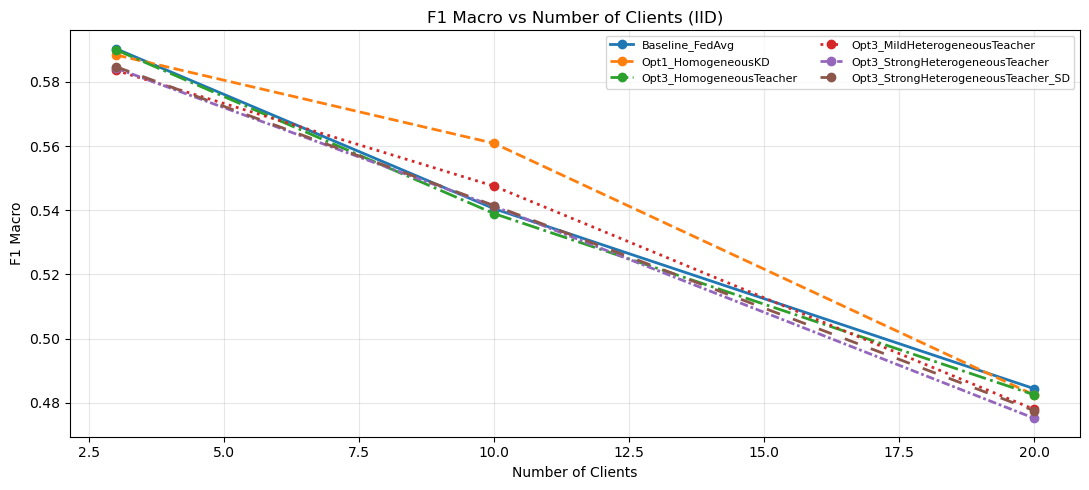

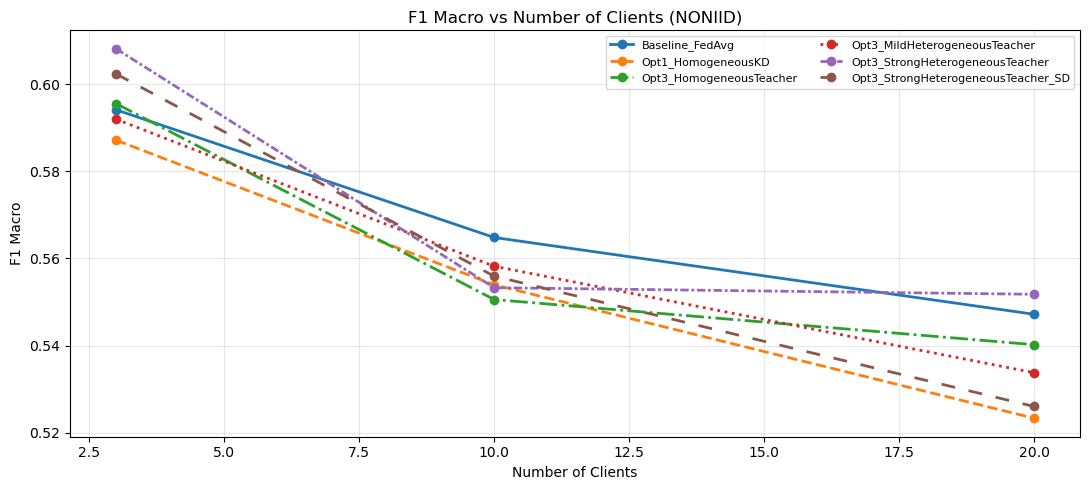

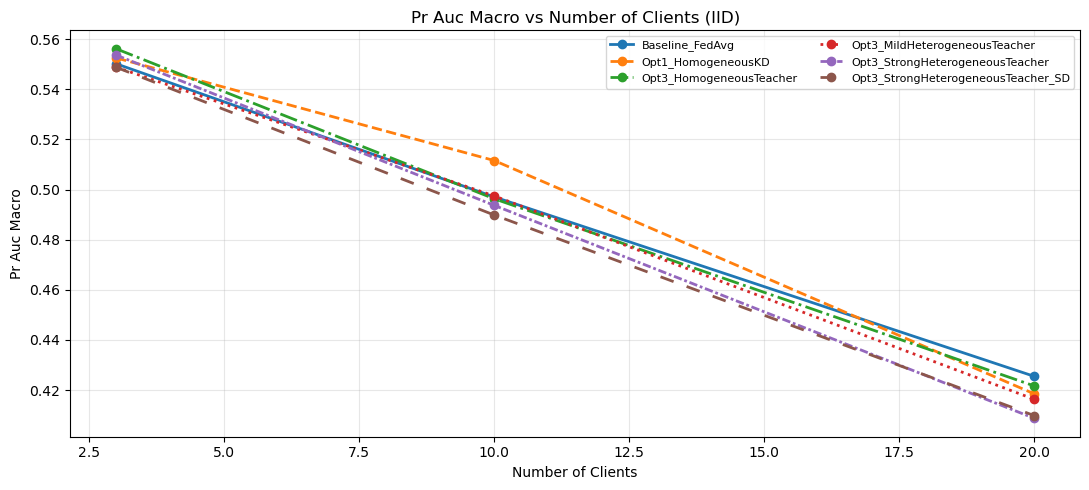

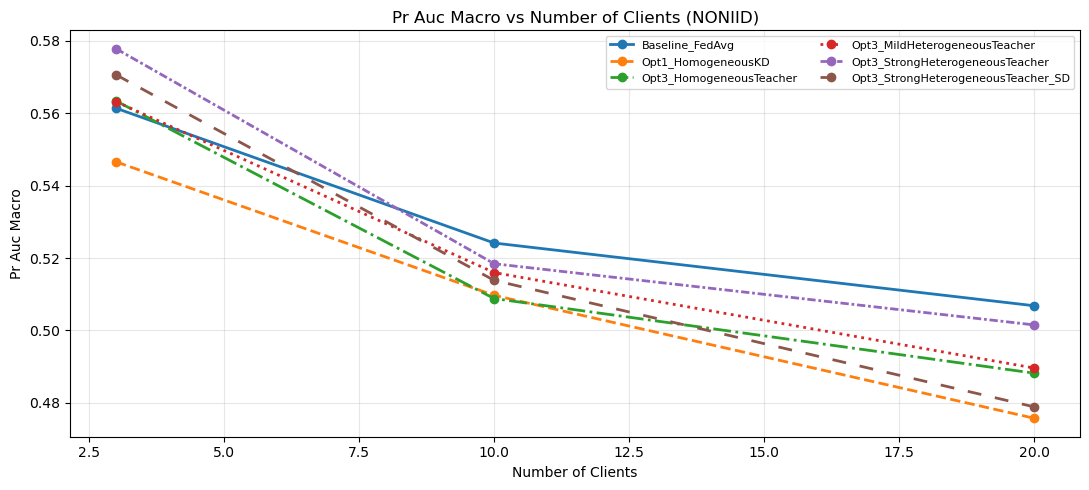

In [45]:
# Example plots

plot_hetero_metric(hetero_kd_df, split_mode="iid", metric="f1_macro", bw=False)
plot_hetero_metric(hetero_kd_df, split_mode="noniid", metric="f1_macro", bw=False)

plot_hetero_metric(hetero_kd_df, split_mode="iid", metric="pr_auc_macro", bw=False)
plot_hetero_metric(hetero_kd_df, split_mode="noniid", metric="pr_auc_macro", bw=False)

### Teacher-Heterogeneity Summary

Aggregate the Option 3 results by teacher-pool regime to see whether mild or
strong local heterogeneity changes shared-student performance.

In [46]:
opt3_only = hetero_kd_df[
    hetero_kd_df["method"].eq("option3")
].copy()

heterogeneity_summary = (
    opt3_only.groupby(["split", "teacher_pool_name"], as_index=False)[[
        "f1_macro",
        "pr_auc_macro",
        "auc_macro",
        "teacher_param_count_mean",
        "time_sec"
    ]]
    .mean()
    .sort_values(by=["split", "f1_macro"], ascending=[True, False])
    .reset_index(drop=True)
)

display(heterogeneity_summary)

,split,teacher_pool_name,f1_macro,pr_auc_macro,auc_macro,teacher_param_count_mean,time_sec
0,iid,homogeneous_caml,0.537143,0.491374,0.848239,1.514055e+07,197.313981
1,iid,mild_heterogeneous,0.536340,0.487532,0.845822,1.513458e+07,198.155043
2,iid,strong_heterogeneous,0.534062,0.484085,0.843592,1.513183e+07,456.448893
3,noniid,strong_heterogeneous,0.566260,0.526854,0.866695,1.513183e+07,458.637497
4,noniid,homogeneous_caml,0.562109,0.520131,0.862643,1.514055e+07,196.999152
5,noniid,mild_heterogeneous,0.561321,0.522938,0.864321,1.513458e+07,197.906458


In [47]:
# Optional relative comparison against the homogeneous-teacher Option 3 baseline

opt3_ref = opt3_only[opt3_only["method_name"] == "Opt3_HomogeneousTeacher"].copy()
opt3_ref = opt3_ref.rename(columns={
    "f1_macro": "ref_f1_macro",
    "pr_auc_macro": "ref_pr_auc_macro",
    "auc_macro": "ref_auc_macro"
})[["split", "clients", "ref_f1_macro", "ref_pr_auc_macro", "ref_auc_macro"]]

opt3_compare = opt3_only.merge(opt3_ref, on=["split", "clients"], how="left")
opt3_compare["delta_f1_macro_vs_homogeneous_teacher"] = opt3_compare["f1_macro"] - opt3_compare["ref_f1_macro"]
opt3_compare["delta_pr_auc_macro_vs_homogeneous_teacher"] = opt3_compare["pr_auc_macro"] - opt3_compare["ref_pr_auc_macro"]
opt3_compare["delta_auc_macro_vs_homogeneous_teacher"] = opt3_compare["auc_macro"] - opt3_compare["ref_auc_macro"]

display(opt3_compare[[
    "split",
    "clients",
    "method_name",
    "teacher_pool_name",
    "f1_macro",
    "delta_f1_macro_vs_homogeneous_teacher",
    "pr_auc_macro",
    "delta_pr_auc_macro_vs_homogeneous_teacher",
    "auc_macro",
    "delta_auc_macro_vs_homogeneous_teacher"
]].sort_values(["split", "clients", "method_name"]).reset_index(drop=True))

,split,clients,method_name,teacher_pool_name,f1_macro,delta_f1_macro_vs_homogeneous_teacher,pr_auc_macro,delta_pr_auc_macro_vs_homogeneous_teacher,auc_macro,delta_auc_macro_vs_homogeneous_teacher
0,iid,3,Opt3_HomogeneousTeacher,homogeneous_caml,0.589960,0.000000,0.556150,0.000000,0.886801,0.000000
1,iid,3,Opt3_MildHeterogeneousTeacher,mild_heterogeneous,0.583538,-0.006422,0.548808,-0.007342,0.880407,-0.006394
2,iid,3,Opt3_StrongHeterogeneousTeacher,strong_heterogeneous,0.584234,-0.005726,0.553643,-0.002507,0.882629,-0.004172
3,iid,3,Opt3_StrongHeterogeneousTeacher_SD,strong_heterogeneous,0.584694,-0.005266,0.548773,-0.007377,0.882023,-0.004778
4,iid,10,Opt3_HomogeneousTeacher,homogeneous_caml,0.538955,0.000000,0.496318,0.000000,0.847429,0.000000
5,iid,10,Opt3_MildHeterogeneousTeacher,mild_heterogeneous,0.547506,0.008551,0.497461,0.001143,0.849724,0.002295
6,iid,10,Opt3_StrongHeterogeneousTeacher,strong_heterogeneous,0.541209,0.002254,0.493695,-0.002623,0.848429,0.001000
7,iid,10,Opt3_StrongHeterogeneousTeacher_SD,strong_heterogeneous,0.541453,0.002498,0.489840,-0.006478,0.844318,-0.003111
8,iid,20,Opt3_HomogeneousTeacher,homogeneous_caml,0.482514,0.000000,0.421654,0.000000,0.810487,0.000000
9,iid,20,Opt3_MildHeterogeneousTeacher,mild_heterogeneous,0.477978,-0.004536,0.416327,-0.005327,0.807335,-0.003152


## Targeted Tuning: Option 3 with Strong Heterogeneous Teachers

After the broader teacher-pool sweep, this section performs a focused tuning
study on the strongest practical Option 3 setting:

- **Method:** Option 3
- **Base algorithm:** FedAvg
- **Teacher pool:** strong heterogeneous

### Phase 1
Tune the core local KD parameters:
- `kd_alpha`
- `kd_temperature`

### Phase 2
Fix the best Phase 1 setting, then tune server-side distillation:
- `server_distill_steps`
- `server_distill_lr`

IID/non-IID remains a stress condition, but the main question here is whether
a shared student can best learn from a diverse set of local teachers.

In [48]:
phase1_client_counts = [3, 10]

phase1_alpha_grid = [0.3, 0.5, 0.7]
phase1_temp_grid = [1.0, 2.0, 4.0]

phase1_split_mode = "noniid"   # can change later if you want an IID counterpart
phase1_config = config.copy()
phase1_config["rounds"] = 10
phase1_local_epochs = 1

phase1_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100
)

print("Phase 1 tuning grid ready.")

Phase 1 tuning grid ready.


In [49]:
# Phase 1 runner with resume support

if os.path.exists(KD_HET_PHASE1_CSV):
    phase1_existing = pd.read_csv(KD_HET_PHASE1_CSV)
    phase1_rows = phase1_existing.to_dict(orient="records")
    phase1_completed = set(
        zip(
            phase1_existing["clients"],
            phase1_existing["kd_alpha"],
            phase1_existing["kd_temperature"]
        )
    )
    print(f"Found existing Phase 1 results at {KD_HET_PHASE1_CSV}")
    print(f"Loaded {len(phase1_existing)} completed rows.")
else:
    phase1_rows = []
    phase1_completed = set()
    print("No existing Phase 1 results found. Starting fresh.")

Found existing Phase 1 results at ..\History\KD_Heterogeneous\heterogeneous_kd\tuning\opt3_heterogeneous_phase1_tuning.csv
Loaded 18 completed rows.


In [50]:
# # Uncomment to run Phase 1 tuning.

# for k in phase1_client_counts:
#     for alpha in phase1_alpha_grid:
#         for temp in phase1_temp_grid:
#             run_key = (k, alpha, temp)

#             if run_key in phase1_completed:
#                 print(f"Skipping completed Phase 1 run: K={k} | alpha={alpha} | T={temp}")
#                 continue

#             print("\n" + "=" * 100)
#             print(f"PHASE 1 | Opt3 Strong Heterogeneous | split={phase1_split_mode} | K={k} | alpha={alpha} | T={temp}")
#             print("=" * 100)

#             try:
#                 phase1_kd_config = copy.deepcopy(kd_config)
#                 phase1_kd_config["teacher_pool_name"] = "strong_heterogeneous"
#                 phase1_kd_config["teacher_pool"] = get_teacher_pool("strong_heterogeneous")
#                 phase1_kd_config["kd_alpha"] = alpha
#                 phase1_kd_config["kd_temperature"] = temp

#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode=phase1_split_mode,
#                     num_clients=k,
#                     local_epochs=phase1_local_epochs,
#                     config=phase1_config,
#                     kd_config=phase1_kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method="option3",
#                     base_algo="FedAvg",
#                     mu=0.0,
#                     server_distill=False,
#                     **phase1_noniid_params
#                 )

#                 row = {
#                     "phase": 1,
#                     "split": phase1_split_mode,
#                     "clients": k,
#                     "method_name": "Opt3_StrongHeterogeneousTeacher",
#                     "method": "option3",
#                     "base_algo": "FedAvg",
#                     "teacher_pool_name": "strong_heterogeneous",
#                     "server_distill": False,
#                     "mu": 0.0,

#                     "local_epochs": phase1_local_epochs,
#                     "rounds": phase1_config["rounds"],

#                     "kd_alpha": alpha,
#                     "kd_temperature": temp,
#                     "teacher_assignment": phase1_kd_config.get("teacher_assignment", None),
#                     "teacher_steps_per_batch": phase1_kd_config.get("teacher_steps_per_batch", None),

#                     "server_distill_steps": None,
#                     "server_distill_lr": None,

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),

#                     "student_param_count": metrics.get("student_param_count"),
#                     "teacher_param_count_mean": metrics.get("teacher_param_count_mean"),
#                     "teacher_param_count_min": metrics.get("teacher_param_count_min"),
#                     "teacher_param_count_max": metrics.get("teacher_param_count_max"),

#                     "time_sec": elapsed,
#                 }

#                 if phase1_split_mode == "noniid":
#                     row.update(phase1_noniid_params)

#                 phase1_rows.append(row)
#                 phase1_completed.add(run_key)

#                 save_dict_rows_to_csv(phase1_rows, KD_HET_PHASE1_CSV)
#                 save_json(
#                     {"rows": [to_serializable_row(r) for r in phase1_rows]},
#                     KD_HET_PHASE1_JSON
#                 )

#                 print(f"Saved Phase 1 result to {KD_HET_PHASE1_CSV}")
#                 print(f"Saved Phase 1 result to {KD_HET_PHASE1_JSON}")

#             except Exception as e:
#                 print(f"FAILED Phase 1: K={k} | alpha={alpha} | T={temp}")
#                 print(f"Reason: {e}")

### Load and Inspect Phase 1 Results

In [51]:
phase1_df = pd.read_csv(KD_HET_PHASE1_CSV)
print("Loaded:", KD_HET_PHASE1_CSV, "rows=", len(phase1_df))
display(phase1_df.head())

Loaded: ..\History\KD_Heterogeneous\heterogeneous_kd\tuning\opt3_heterogeneous_phase1_tuning.csv rows= 18


,phase,split,clients,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.721996,0.5,10,0.85,100
1,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.488234,0.5,10,0.85,100
2,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.497688,0.5,10,0.85,100
3,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.570101,0.5,10,0.85,100
4,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.520585,0.5,10,0.85,100


In [52]:
phase1_summary = phase1_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase1_summary)

phase1_pivot = phase1_df.pivot_table(
    index=["clients", "kd_alpha"],
    columns="kd_temperature",
    values="f1_macro"
)

display(phase1_pivot)

,phase,split,clients,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.721996,0.5,10,0.85,100
1,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.488234,0.5,10,0.85,100
2,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.616795,0.5,10,0.85,100
3,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.586055,0.5,10,0.85,100
4,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.570101,0.5,10,0.85,100
5,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.513763,0.5,10,0.85,100
6,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.497688,0.5,10,0.85,100
7,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.520585,0.5,10,0.85,100
8,1,noniid,3,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.474724,0.5,10,0.85,100
9,1,noniid,10,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15139271.6,15099528,15189580,44.289790,0.5,10,0.85,100


kd_temperature         1.0       2.0       4.0
clients kd_alpha                              
3       0.3       0.504100  0.503933  0.494726
        0.5       0.499077  0.494375  0.501147
        0.7       0.494813  0.502587  0.492215
10      0.3       0.359911  0.363326  0.352158
        0.5       0.359063  0.359996  0.373410
        0.7       0.378577  0.370077  0.375990

In [53]:
phase1_best_per_k = (
    phase1_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase1_best_per_k)

,clients,phase,split,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,3,1,noniid,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,28.721996,0.5,10,0.85,100
1,10,1,noniid,Opt3_StrongHeterogeneousTeacher,option3,FedAvg,strong_heterogeneous,False,0.0,1,...,per-label,15100221,15139271.6,15099528,15189580,44.289790,0.5,10,0.85,100


In [54]:
phase1_global_summary = (
    phase1_df.groupby(["kd_alpha", "kd_temperature"], as_index=False)
    .agg({
        "f1_macro": "mean",
        "pr_auc_macro": "mean",
        "auc_macro": "mean",
        "time_sec": "mean"
    })
    .sort_values(
        by=["f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(phase1_global_summary)

best_phase1_alpha = float(phase1_global_summary.loc[0, "kd_alpha"])
best_phase1_temp = float(phase1_global_summary.loc[0, "kd_temperature"])

print(f"Best Phase 1 global setting: kd_alpha={best_phase1_alpha}, kd_temperature={best_phase1_temp}")

,kd_alpha,kd_temperature,f1_macro,pr_auc_macro,auc_macro,time_sec
0,0.5,4.0,0.437278,0.369527,0.777954,36.283299
1,0.7,1.0,0.436695,0.376153,0.780684,36.401777
2,0.7,2.0,0.436332,0.373082,0.774779,36.500683
3,0.7,4.0,0.434102,0.371320,0.777690,36.343023
4,0.3,2.0,0.433630,0.365156,0.776166,36.319652
5,0.3,1.0,0.432006,0.369174,0.777277,36.486122
6,0.5,1.0,0.429070,0.370169,0.778417,36.391624
7,0.5,2.0,0.427186,0.364735,0.775428,36.392322
8,0.3,4.0,0.423442,0.357599,0.766839,36.311644


Best Phase 1 global setting: kd_alpha=0.5, kd_temperature=4.0


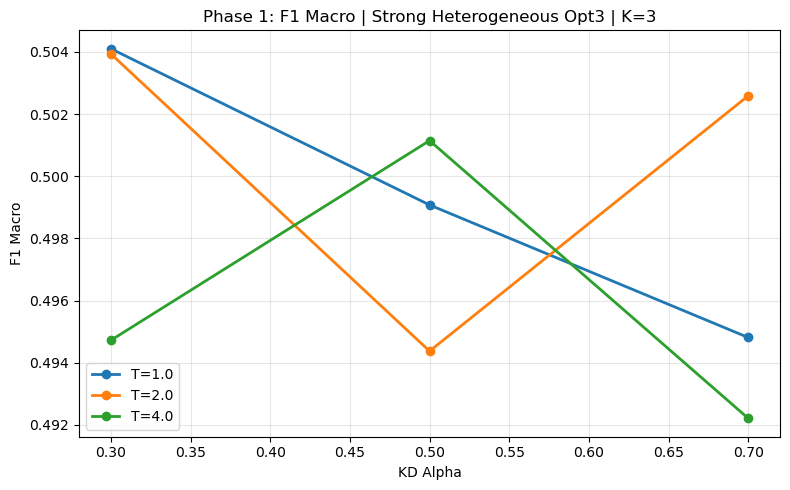

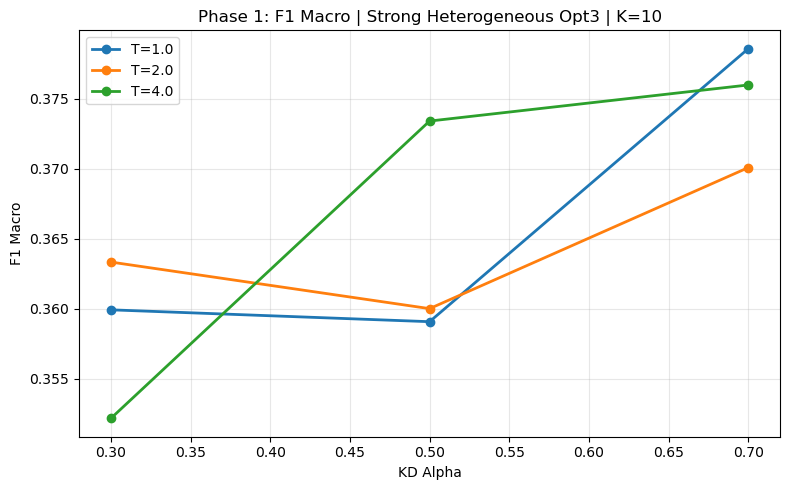

In [55]:
def plot_phase1_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    temps = sorted(d["kd_temperature"].unique())

    plt.figure(figsize=(8, 5))
    for temp in temps:
        g = d[d["kd_temperature"] == temp].sort_values("kd_alpha")
        plt.plot(
            g["kd_alpha"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"T={temp}"
        )

    plt.xlabel("KD Alpha")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Phase 1: {metric.replace('_', ' ').title()} | Strong Heterogeneous Opt3 | K={clients_value}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase1_metric(phase1_df, clients_value=3, metric="f1_macro")
plot_phase1_metric(phase1_df, clients_value=10, metric="f1_macro")

### Phase 2: Server Distillation Tuning on Top of Overridden Phase 1 Setting

We manually override the Phase 1 choice here to emphasize the stronger /
more realistic fragmentation setting. Instead of using the mean-best setting
across K=3 and K=10, we use:
- kd_alpha = 0.7
- kd_temperature = 1.0

This matches the stronger K=10 result and keeps Phase 2 focused on the
heterogeneous-hospital setting we care about most.

In [56]:
# Manual override from Phase 1 before Phase 2

best_phase1_alpha = 0.7
best_phase1_temp = 1.0

print(f"Phase 2 override: kd_alpha={best_phase1_alpha}, kd_temperature={best_phase1_temp}")

phase2_client_counts = [3, 10]

phase2_steps_grid = [5, 10, 20]
phase2_lr_grid = [0.001, 0.002, 0.005]

phase2_split_mode = "noniid"
phase2_config = config.copy()
phase2_config["rounds"] = 10
phase2_local_epochs = 1

phase2_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100
)

print("Phase 2 server-distillation tuning grid ready.")

Phase 2 override: kd_alpha=0.7, kd_temperature=1.0
Phase 2 server-distillation tuning grid ready.


In [57]:
# Phase 2 runner with resume support

if os.path.exists(KD_HET_PHASE2_CSV):
    phase2_existing = pd.read_csv(KD_HET_PHASE2_CSV)
    phase2_rows = phase2_existing.to_dict(orient="records")
    phase2_completed = set(
        zip(
            phase2_existing["clients"],
            phase2_existing["server_distill_steps"],
            phase2_existing["server_distill_lr"]
        )
    )
    print(f"Found existing Phase 2 results at {KD_HET_PHASE2_CSV}")
    print(f"Loaded {len(phase2_existing)} completed rows.")
else:
    phase2_rows = []
    phase2_completed = set()
    print("No existing Phase 2 results found. Starting fresh.")

Found existing Phase 2 results at ..\History\KD_Heterogeneous\heterogeneous_kd\tuning\opt3_heterogeneous_phase2_server_distill.csv
Loaded 18 completed rows.


In [58]:
# # Uncomment to run Phase 2 tuning.

# for k in phase2_client_counts:
#     for sd_steps in phase2_steps_grid:
#         for sd_lr in phase2_lr_grid:
#             run_key = (k, sd_steps, sd_lr)

#             if run_key in phase2_completed:
#                 print(f"Skipping completed Phase 2 run: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
#                 continue

#             print("\n" + "=" * 100)
#             print(
#                 f"PHASE 2 | Opt3 Strong Heterogeneous + SD | split={phase2_split_mode} | "
#                 f"K={k} | alpha={best_phase1_alpha} | T={best_phase1_temp} | "
#                 f"SD_steps={sd_steps} | SD_lr={sd_lr}"
#             )
#             print("=" * 100)

#             try:
#                 phase2_kd_config = copy.deepcopy(kd_config)
#                 phase2_kd_config["teacher_pool_name"] = "strong_heterogeneous"
#                 phase2_kd_config["teacher_pool"] = get_teacher_pool("strong_heterogeneous")
#                 phase2_kd_config["kd_alpha"] = best_phase1_alpha
#                 phase2_kd_config["kd_temperature"] = best_phase1_temp
#                 phase2_kd_config["server_distill_steps"] = sd_steps
#                 phase2_kd_config["server_distill_lr"] = sd_lr

#                 metrics, elapsed = run_fl_kd_once(
#                     split_mode=phase2_split_mode,
#                     num_clients=k,
#                     local_epochs=phase2_local_epochs,
#                     config=phase2_config,
#                     kd_config=phase2_kd_config,
#                     train_dataset=train_dataset,
#                     val_loader=val_loader,
#                     test_loader=test_loader,
#                     device=device,
#                     seed=42,
#                     method="option3",
#                     base_algo="FedAvg",
#                     mu=0.0,
#                     server_distill=True,
#                     **phase2_noniid_params
#                 )

#                 row = {
#                     "phase": 2,
#                     "split": phase2_split_mode,
#                     "clients": k,
#                     "method_name": "Opt3_StrongHeterogeneousTeacher_SD",
#                     "method": "option3",
#                     "base_algo": "FedAvg",
#                     "teacher_pool_name": "strong_heterogeneous",
#                     "server_distill": True,
#                     "mu": 0.0,

#                     "local_epochs": phase2_local_epochs,
#                     "rounds": phase2_config["rounds"],

#                     "kd_alpha": best_phase1_alpha,
#                     "kd_temperature": best_phase1_temp,
#                     "teacher_assignment": phase2_kd_config.get("teacher_assignment", None),
#                     "teacher_steps_per_batch": phase2_kd_config.get("teacher_steps_per_batch", None),

#                     "server_distill_steps": sd_steps,
#                     "server_distill_lr": sd_lr,

#                     "f1_macro": metrics.get("f1_macro"),
#                     "f1_micro": metrics.get("f1_micro"),
#                     "pr_auc_macro": metrics.get("pr_auc_macro"),
#                     "pr_auc_micro": metrics.get("pr_auc_micro"),
#                     "auc_macro": metrics.get("auc_macro"),
#                     "auc_micro": metrics.get("auc_micro"),
#                     "best_f1_micro": metrics.get("best_f1_micro"),
#                     "best_thr": metrics.get("best_thr"),

#                     "student_param_count": metrics.get("student_param_count"),
#                     "teacher_param_count_mean": metrics.get("teacher_param_count_mean"),
#                     "teacher_param_count_min": metrics.get("teacher_param_count_min"),
#                     "teacher_param_count_max": metrics.get("teacher_param_count_max"),

#                     "time_sec": elapsed,
#                 }

#                 if phase2_split_mode == "noniid":
#                     row.update(phase2_noniid_params)

#                 phase2_rows.append(row)
#                 phase2_completed.add(run_key)

#                 save_dict_rows_to_csv(phase2_rows, KD_HET_PHASE2_CSV)
#                 save_json(
#                     {"rows": [to_serializable_row(r) for r in phase2_rows]},
#                     KD_HET_PHASE2_JSON
#                 )

#                 print(f"Saved Phase 2 result to {KD_HET_PHASE2_CSV}")
#                 print(f"Saved Phase 2 result to {KD_HET_PHASE2_JSON}")

#             except Exception as e:
#                 print(f"FAILED Phase 2: K={k} | SD_steps={sd_steps} | SD_lr={sd_lr}")
#                 print(f"Reason: {e}")

### Load and Inspect Phase 2 Results

In [59]:
phase2_df = pd.read_csv(KD_HET_PHASE2_CSV)
print("Loaded:", KD_HET_PHASE2_CSV, "rows=", len(phase2_df))
display(phase2_df.head())

Loaded: ..\History\KD_Heterogeneous\heterogeneous_kd\tuning\opt3_heterogeneous_phase2_server_distill.csv rows= 18


,phase,split,clients,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,90.526995,0.5,10,0.85,100
1,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.231960,0.5,10,0.85,100
2,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.015738,0.5,10,0.85,100
3,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.753998,0.5,10,0.85,100
4,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.639100,0.5,10,0.85,100


In [60]:
phase2_summary = phase2_df.sort_values(
    by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(phase2_summary)

phase2_pivot = phase2_df.pivot_table(
    index=["clients", "server_distill_steps"],
    columns="server_distill_lr",
    values="f1_macro"
)

display(phase2_pivot)

,phase,split,clients,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.231960,0.5,10,0.85,100
1,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,90.526995,0.5,10,0.85,100
2,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,74.730736,0.5,10,0.85,100
3,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,75.000286,0.5,10,0.85,100
4,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.015738,0.5,10,0.85,100
5,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,75.591913,0.5,10,0.85,100
6,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.639100,0.5,10,0.85,100
7,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.813864,0.5,10,0.85,100
8,2,noniid,3,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.753998,0.5,10,0.85,100
9,2,noniid,10,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15139271.6,15099528,15189580,199.886869,0.5,10,0.85,100


server_distill_lr                0.001     0.002     0.005
clients server_distill_steps                              
3       5                     0.500092  0.505609  0.497796
        10                    0.491800  0.495853  0.494453
        20                    0.500004  0.498241  0.495854
10      5                     0.380966  0.375723  0.385135
        10                    0.372600  0.377547  0.384425
        20                    0.393128  0.393802  0.395410

In [61]:
phase2_best_per_k = (
    phase2_df.sort_values(
        by=["clients", "f1_macro", "pr_auc_macro", "auc_macro"],
        ascending=[True, False, False, False]
    )
    .groupby("clients", as_index=False)
    .first()
)

display(phase2_best_per_k)

,clients,phase,split,method_name,method,base_algo,teacher_pool_name,server_distill,mu,local_epochs,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,3,2,noniid,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15116938.0,15099528,15140550,73.231960,0.5,10,0.85,100
1,10,2,noniid,Opt3_StrongHeterogeneousTeacher_SD,option3,FedAvg,strong_heterogeneous,True,0.0,1,...,per-label,15100221,15139271.6,15099528,15189580,199.886869,0.5,10,0.85,100


In [62]:
# Use the manual override values for the Phase 1 comparison table as well

phase1_best_compare = pd.DataFrame([
    {
        "clients": 3,
        "kd_alpha": best_phase1_alpha,
        "kd_temperature": best_phase1_temp,
        "variant": "Opt3_StrongHeterogeneous_Best_Phase1_Override"
    },
    {
        "clients": 10,
        "kd_alpha": best_phase1_alpha,
        "kd_temperature": best_phase1_temp,
        "variant": "Opt3_StrongHeterogeneous_Best_Phase1_Override"
    }
])

# attach the actual Phase 1 metrics for the overridden setting if present
phase1_override_rows = phase1_df[
    (phase1_df["kd_alpha"] == best_phase1_alpha) &
    (phase1_df["kd_temperature"] == best_phase1_temp) &
    (phase1_df["clients"].isin([3, 10]))
][[
    "clients",
    "f1_macro",
    "pr_auc_macro",
    "auc_macro",
    "time_sec"
]].copy()

phase1_best_compare = phase1_best_compare.merge(
    phase1_override_rows,
    on="clients",
    how="left"
)

phase2_best_compare = phase2_best_per_k[[
    "clients",
    "server_distill_steps",
    "server_distill_lr",
    "f1_macro",
    "pr_auc_macro",
    "auc_macro",
    "time_sec"
]].copy()
phase2_best_compare["variant"] = "Opt3_StrongHeterogeneous_SD_Best_Phase2"

display(phase1_best_compare)
display(phase2_best_compare)

,clients,kd_alpha,kd_temperature,variant,f1_macro,pr_auc_macro,auc_macro,time_sec
0,3,0.7,1.0,Opt3_StrongHeterogeneous_Best_Phase1_Override,0.494813,0.436545,0.820520,28.513763
1,10,0.7,1.0,Opt3_StrongHeterogeneous_Best_Phase1_Override,0.378577,0.315761,0.740848,44.289790


,clients,server_distill_steps,server_distill_lr,f1_macro,pr_auc_macro,auc_macro,time_sec,variant
0,3,5,0.002,0.505609,0.448603,0.828046,73.231960,Opt3_StrongHeterogeneous_SD_Best_Phase2
1,10,20,0.005,0.395410,0.323034,0.748231,199.886869,Opt3_StrongHeterogeneous_SD_Best_Phase2


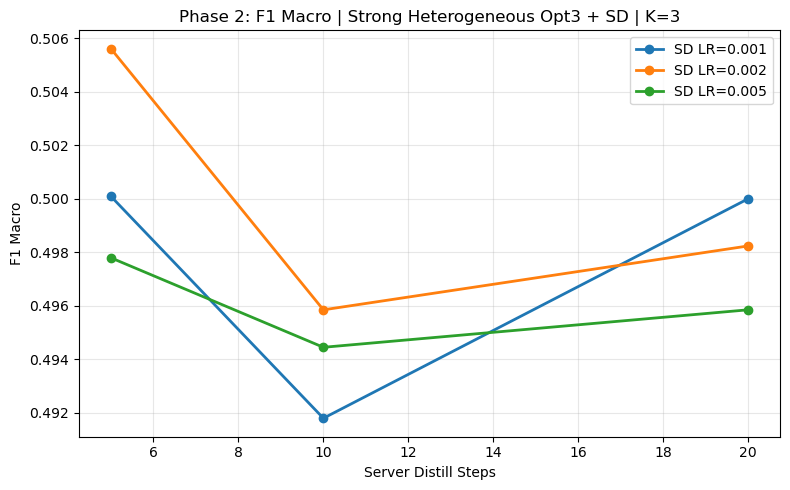

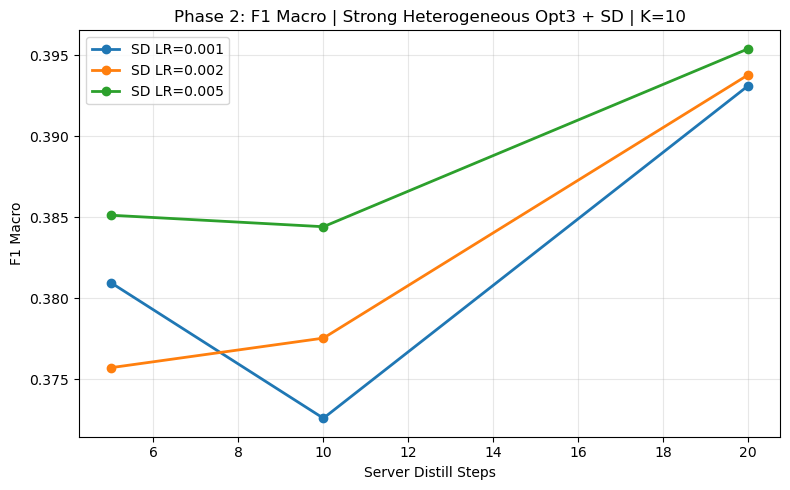

In [63]:
def plot_phase2_metric(df, clients_value: int, metric: str = "f1_macro"):
    d = df[df["clients"] == clients_value].copy()
    lrs = sorted(d["server_distill_lr"].unique())

    plt.figure(figsize=(8, 5))
    for sd_lr in lrs:
        g = d[d["server_distill_lr"] == sd_lr].sort_values("server_distill_steps")
        plt.plot(
            g["server_distill_steps"],
            g[metric],
            marker="o",
            linewidth=2,
            label=f"SD LR={sd_lr}"
        )

    plt.xlabel("Server Distill Steps")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"Phase 2: {metric.replace('_', ' ').title()} | Strong Heterogeneous Opt3 + SD | K={clients_value}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_phase2_metric(phase2_df, clients_value=3, metric="f1_macro")
plot_phase2_metric(phase2_df, clients_value=10, metric="f1_macro")

In [64]:
final_compare = []

for k in sorted(set(phase1_best_compare["clients"]).intersection(set(phase2_best_per_k["clients"]))):
    p1 = phase1_best_compare[phase1_best_compare["clients"] == k].iloc[0]
    p2 = phase2_best_per_k[phase2_best_per_k["clients"] == k].iloc[0]

    final_compare.append({
        "clients": k,

        "best_phase1_alpha": p1["kd_alpha"],
        "best_phase1_temp": p1["kd_temperature"],
        "phase1_f1_macro": p1["f1_macro"],
        "phase1_pr_auc_macro": p1["pr_auc_macro"],
        "phase1_auc_macro": p1["auc_macro"],

        "best_phase2_sd_steps": p2["server_distill_steps"],
        "best_phase2_sd_lr": p2["server_distill_lr"],
        "phase2_f1_macro": p2["f1_macro"],
        "phase2_pr_auc_macro": p2["pr_auc_macro"],
        "phase2_auc_macro": p2["auc_macro"],

        "delta_f1_macro": p2["f1_macro"] - p1["f1_macro"],
        "delta_pr_auc_macro": p2["pr_auc_macro"] - p1["pr_auc_macro"],
        "delta_auc_macro": p2["auc_macro"] - p1["auc_macro"],
    })

final_compare_df = pd.DataFrame(final_compare)
display(final_compare_df)

,clients,best_phase1_alpha,best_phase1_temp,phase1_f1_macro,phase1_pr_auc_macro,phase1_auc_macro,best_phase2_sd_steps,best_phase2_sd_lr,phase2_f1_macro,phase2_pr_auc_macro,phase2_auc_macro,delta_f1_macro,delta_pr_auc_macro,delta_auc_macro
0,3,0.7,1.0,0.494813,0.436545,0.820520,5,0.002,0.505609,0.448603,0.828046,0.010796,0.012058,0.007526
1,10,0.7,1.0,0.378577,0.315761,0.740848,20,0.005,0.395410,0.323034,0.748231,0.016833,0.007273,0.007383


## Final Focused Sweep: Tuned Option 3 with Strong Heterogeneous Teachers

This section runs the final comparison using the tuned strong-heterogeneous
Option 3 setting from the earlier tuning phases.

Methods compared:
- Baseline FedAvg
- Tuned Option 3 with strong heterogeneous teachers
- Tuned Option 3 with strong heterogeneous teachers + server distillation

We run the final sweep under both:
- non-IID client partitions
- IID client partitions

Results are saved incrementally with resume support.

In [65]:
# Final tuned KD config from Phase 1 / Phase 2

final_opt3_kd_config = copy.deepcopy(kd_config)
final_opt3_kd_config["teacher_pool_name"] = "strong_heterogeneous"
final_opt3_kd_config["teacher_pool"] = get_teacher_pool("strong_heterogeneous")
final_opt3_kd_config["kd_alpha"] = best_phase1_alpha
final_opt3_kd_config["kd_temperature"] = best_phase1_temp

# Keep these defaults unless you want to override them manually later
best_phase2_sd_steps = int(phase2_best_per_k.sort_values("f1_macro", ascending=False).iloc[0]["server_distill_steps"])
best_phase2_sd_lr = float(phase2_best_per_k.sort_values("f1_macro", ascending=False).iloc[0]["server_distill_lr"])

final_opt3_kd_config["server_distill_steps"] = best_phase2_sd_steps
final_opt3_kd_config["server_distill_lr"] = best_phase2_sd_lr

print("Final tuned heterogeneous Option 3 config:")
print(f"  kd_alpha            = {final_opt3_kd_config['kd_alpha']}")
print(f"  kd_temperature      = {final_opt3_kd_config['kd_temperature']}")
print(f"  teacher_pool_name   = {final_opt3_kd_config['teacher_pool_name']}")
print(f"  server_distill_steps= {final_opt3_kd_config['server_distill_steps']}")
print(f"  server_distill_lr   = {final_opt3_kd_config['server_distill_lr']}")

Final tuned heterogeneous Option 3 config:
  kd_alpha            = 0.7
  kd_temperature      = 1.0
  teacher_pool_name   = strong_heterogeneous
  server_distill_steps= 5
  server_distill_lr   = 0.002


In [66]:
final_client_counts = [2, 3, 4, 8, 10, 12, 15, 20]

final_config = config.copy()
final_config["rounds"] = 100
final_local_epochs = 3

final_noniid_params = dict(
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100
)

FINAL_HET_METHODS = [
    dict(
        method_name="Baseline_FedAvg",
        method="baseline",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False
    ),
    dict(
        method_name="Opt3_StrongHeterogeneous_Tuned",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=False
    ),
    dict(
        method_name="Opt3_StrongHeterogeneous_Tuned_SD",
        method="option3",
        base_algo="FedAvg",
        mu=0.0,
        server_distill=True
    ),
]

KD_HET_FINAL_NONIID_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_noniid.csv")
KD_HET_FINAL_NONIID_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_noniid.json")

KD_HET_FINAL_IID_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_iid.csv")
KD_HET_FINAL_IID_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_iid.json")

KD_HET_FINAL_COMBINED_CSV  = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_combined.csv")
KD_HET_FINAL_COMBINED_JSON = os.path.join(HET_KD_FINAL_DIR, "opt3_strong_heterogeneous_final_combined.json")

print("Final sweep paths ready.")

Final sweep paths ready.


### Final Non-IID Sweep

In [67]:
# Non-IID final sweep runner with resume support

if os.path.exists(KD_HET_FINAL_NONIID_CSV):
    final_noniid_existing = pd.read_csv(KD_HET_FINAL_NONIID_CSV)
    final_noniid_rows = final_noniid_existing.to_dict(orient="records")
    final_noniid_completed = set(
        zip(
            final_noniid_existing["method_name"],
            final_noniid_existing["clients"]
        )
    )
    print(f"Found existing final non-IID results at {KD_HET_FINAL_NONIID_CSV}")
    print(f"Loaded {len(final_noniid_existing)} completed rows.")
else:
    final_noniid_rows = []
    final_noniid_completed = set()
    print("No existing final non-IID results found. Starting fresh.")

Found existing final non-IID results at ..\History\KD_Heterogeneous\heterogeneous_kd\final\opt3_strong_heterogeneous_final_noniid.csv
Loaded 24 completed rows.


In [68]:
# # Uncomment to run the final non-IID sweep.

# for m in FINAL_HET_METHODS:
#     for k in final_client_counts:
#         run_key = (m["method_name"], k)

#         if run_key in final_noniid_completed:
#             print(f"Skipping completed run: {m['method_name']} | K={k}")
#             continue

#         print("\n" + "=" * 100)
#         print(f"FINAL NONIID | {m['method_name']} | K={k}")
#         print("=" * 100)

#         try:
#             metrics, elapsed = run_fl_kd_once(
#                 split_mode="noniid",
#                 num_clients=k,
#                 local_epochs=final_local_epochs,
#                 config=final_config,
#                 kd_config=final_opt3_kd_config,
#                 train_dataset=train_dataset,
#                 val_loader=val_loader,
#                 test_loader=test_loader,
#                 device=device,
#                 seed=42,
#                 method=m["method"],
#                 base_algo=m["base_algo"],
#                 mu=m["mu"],
#                 server_distill=m["server_distill"],
#                 **final_noniid_params
#             )

#             row = {
#                 "split": "noniid",
#                 "clients": k,

#                 "method_name": m["method_name"],
#                 "method": m["method"],
#                 "base_algo": m["base_algo"],
#                 "mu": m["mu"],
#                 "server_distill": m["server_distill"],

#                 "local_epochs": final_local_epochs,
#                 "rounds": final_config["rounds"],

#                 "kd_alpha": final_opt3_kd_config["kd_alpha"],
#                 "kd_temperature": final_opt3_kd_config["kd_temperature"],
#                 "teacher_pool_name": final_opt3_kd_config["teacher_pool_name"],
#                 "teacher_assignment": final_opt3_kd_config.get("teacher_assignment", None),
#                 "teacher_steps_per_batch": final_opt3_kd_config.get("teacher_steps_per_batch", None),
#                 "server_distill_steps": (
#                     final_opt3_kd_config["server_distill_steps"] if m["server_distill"] else None
#                 ),
#                 "server_distill_lr": (
#                     final_opt3_kd_config["server_distill_lr"] if m["server_distill"] else None
#                 ),

#                 "f1_macro": metrics.get("f1_macro"),
#                 "f1_micro": metrics.get("f1_micro"),
#                 "pr_auc_macro": metrics.get("pr_auc_macro"),
#                 "pr_auc_micro": metrics.get("pr_auc_micro"),
#                 "auc_macro": metrics.get("auc_macro"),
#                 "auc_micro": metrics.get("auc_micro"),
#                 "best_f1_micro": metrics.get("best_f1_micro"),
#                 "best_thr": metrics.get("best_thr"),

#                 "student_param_count": metrics.get("student_param_count"),
#                 "teacher_param_count_mean": metrics.get("teacher_param_count_mean"),
#                 "teacher_param_count_min": metrics.get("teacher_param_count_min"),
#                 "teacher_param_count_max": metrics.get("teacher_param_count_max"),

#                 "time_sec": elapsed,

#                 "size_alpha": final_noniid_params["size_alpha"],
#                 "labels_per_client": final_noniid_params["labels_per_client"],
#                 "bias_strength": final_noniid_params["bias_strength"],
#                 "min_size_per_client": final_noniid_params["min_size_per_client"],
#             }

#             final_noniid_rows.append(row)
#             final_noniid_completed.add(run_key)

#             save_dict_rows_to_csv(final_noniid_rows, KD_HET_FINAL_NONIID_CSV)
#             save_json(
#                 {"rows": [to_serializable_row(r) for r in final_noniid_rows]},
#                 KD_HET_FINAL_NONIID_JSON
#             )

#             print(f"Saved result to {KD_HET_FINAL_NONIID_CSV}")
#             print(f"Saved result to {KD_HET_FINAL_NONIID_JSON}")

#         except Exception as e:
#             print(f"FAILED: {m['method_name']} | K={k}")
#             print(f"Reason: {e}")

In [69]:
final_opt3_noniid_df = pd.read_csv(KD_HET_FINAL_NONIID_CSV)
print("Loaded:", KD_HET_FINAL_NONIID_CSV, "rows=", len(final_opt3_noniid_df))
display(final_opt3_noniid_df.head())

Loaded: ..\History\KD_Heterogeneous\heterogeneous_kd\final\opt3_strong_heterogeneous_final_noniid.csv rows= 24


,split,clients,method_name,method,base_algo,mu,server_distill,local_epochs,rounds,kd_alpha,...,best_thr,student_param_count,teacher_param_count_mean,teacher_param_count_min,teacher_param_count_max,time_sec,size_alpha,labels_per_client,bias_strength,min_size_per_client
0,noniid,2,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,per-label,15100221,NaN,NaN,NaN,268.632851,0.5,10,0.85,100
1,noniid,3,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,per-label,15100221,NaN,NaN,NaN,275.884696,0.5,10,0.85,100
2,noniid,4,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,per-label,15100221,NaN,NaN,NaN,283.152234,0.5,10,0.85,100
3,noniid,8,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,per-label,15100221,NaN,NaN,NaN,316.224948,0.5,10,0.85,100
4,noniid,10,Baseline_FedAvg,baseline,FedAvg,0.0,False,3,100,0.7,...,per-label,15100221,NaN,NaN,NaN,332.348833,0.5,10,0.85,100


In [70]:
final_opt3_noniid_pivot = final_opt3_noniid_df.pivot_table(
    index="clients",
    columns="method_name",
    values="f1_macro"
)
display(final_opt3_noniid_pivot)

method_name,Baseline_FedAvg,Opt3_StrongHeterogeneous_Tuned,Opt3_StrongHeterogeneous_Tuned_SD
clients,,,
2,0.611911,0.619382,0.626564
3,0.615033,0.623514,0.625806
4,0.602350,0.622228,0.621497
8,0.611800,0.611900,0.622095
10,0.613708,0.603286,0.594807
12,0.580394,0.591250,0.593737
15,0.590251,0.600278,0.592072
20,0.573887,0.583610,0.581609


### Final IID Sweep

In [71]:
# IID final sweep runner with resume support

if os.path.exists(KD_HET_FINAL_IID_CSV):
    final_iid_existing = pd.read_csv(KD_HET_FINAL_IID_CSV)
    final_iid_rows = final_iid_existing.to_dict(orient="records")
    final_iid_completed = set(
        zip(
            final_iid_existing["method_name"],
            final_iid_existing["clients"]
        )
    )
    print(f"Found existing final IID results at {KD_HET_FINAL_IID_CSV}")
    print(f"Loaded {len(final_iid_existing)} completed rows.")
else:
    final_iid_rows = []
    final_iid_completed = set()
    print("No existing final IID results found. Starting fresh.")

No existing final IID results found. Starting fresh.


In [73]:
# Uncomment to run the final IID sweep.

for m in FINAL_HET_METHODS:
    for k in final_client_counts:
        run_key = (m["method_name"], k)

        if run_key in final_iid_completed:
            print(f"Skipping completed run: {m['method_name']} | K={k}")
            continue

        print("\n" + "=" * 100)
        print(f"FINAL IID | {m['method_name']} | K={k}")
        print("=" * 100)

        try:
            metrics, elapsed = run_fl_kd_once(
                split_mode="iid",
                num_clients=k,
                local_epochs=final_local_epochs,
                config=final_config,
                kd_config=final_opt3_kd_config,
                train_dataset=train_dataset,
                val_loader=val_loader,
                test_loader=test_loader,
                device=device,
                seed=42,
                method=m["method"],
                base_algo=m["base_algo"],
                mu=m["mu"],
                server_distill=m["server_distill"]
            )

            row = {
                "split": "iid",
                "clients": k,

                "method_name": m["method_name"],
                "method": m["method"],
                "base_algo": m["base_algo"],
                "mu": m["mu"],
                "server_distill": m["server_distill"],

                "local_epochs": final_local_epochs,
                "rounds": final_config["rounds"],

                "kd_alpha": final_opt3_kd_config["kd_alpha"],
                "kd_temperature": final_opt3_kd_config["kd_temperature"],
                "teacher_pool_name": final_opt3_kd_config["teacher_pool_name"],
                "teacher_assignment": final_opt3_kd_config.get("teacher_assignment", None),
                "teacher_steps_per_batch": final_opt3_kd_config.get("teacher_steps_per_batch", None),
                "server_distill_steps": (
                    final_opt3_kd_config["server_distill_steps"] if m["server_distill"] else None
                ),
                "server_distill_lr": (
                    final_opt3_kd_config["server_distill_lr"] if m["server_distill"] else None
                ),

                "f1_macro": metrics.get("f1_macro"),
                "f1_micro": metrics.get("f1_micro"),
                "pr_auc_macro": metrics.get("pr_auc_macro"),
                "pr_auc_micro": metrics.get("pr_auc_micro"),
                "auc_macro": metrics.get("auc_macro"),
                "auc_micro": metrics.get("auc_micro"),
                "best_f1_micro": metrics.get("best_f1_micro"),
                "best_thr": metrics.get("best_thr"),

                "student_param_count": metrics.get("student_param_count"),
                "teacher_param_count_mean": metrics.get("teacher_param_count_mean"),
                "teacher_param_count_min": metrics.get("teacher_param_count_min"),
                "teacher_param_count_max": metrics.get("teacher_param_count_max"),

                "time_sec": elapsed,
            }

            final_iid_rows.append(row)
            final_iid_completed.add(run_key)

            save_dict_rows_to_csv(final_iid_rows, KD_HET_FINAL_IID_CSV)
            save_json(
                {"rows": [to_serializable_row(r) for r in final_iid_rows]},
                KD_HET_FINAL_IID_JSON
            )

            print(f"Saved result to {KD_HET_FINAL_IID_CSV}")
            print(f"Saved result to {KD_HET_FINAL_IID_JSON}")

        except Exception as e:
            print(f"FAILED: {m['method_name']} | K={k}")
            print(f"Reason: {e}")


FINAL IID | Baseline_FedAvg | K=2


baseline | FedAvg | iid | K=2 | E=3: 100%|██████████| 100/100 [19:28<00:00, 11.69s/it]


[Per-Label Thresholds] Macro F1=0.5987
[Eval] Avg loss=0.3879 | F1_micro=0.6282 | F1_macro=0.6227 | AUC_macro=0.9024 | AUC_micro=0.9190 | PR-AUC_macro=0.5958 | PR-AUC_micro=0.6477 | Best_F1=0.6282 @ thr=per-label | Avg labels/sample=8.10
Saved CSV: ..\History\KD_Heterogeneous\heterogeneous_kd\final\opt3_strong_heterogeneous_final_iid.csv
Saved result to ..\History\KD_Heterogeneous\heterogeneous_kd\final\opt3_strong_heterogeneous_final_iid.csv
Saved result to ..\History\KD_Heterogeneous\heterogeneous_kd\final\opt3_strong_heterogeneous_final_iid.json

FINAL IID | Baseline_FedAvg | K=3


baseline | FedAvg | iid | K=3 | E=3:   5%|▌         | 5/100 [01:05<20:42, 13.08s/it]


KeyboardInterrupt: 

In [ ]:
final_opt3_iid_df = pd.read_csv(KD_HET_FINAL_IID_CSV)
print("Loaded:", KD_HET_FINAL_IID_CSV, "rows=", len(final_opt3_iid_df))
display(final_opt3_iid_df.head())

### Combine IID and non-IID Final Results

In [ ]:
df_final_combined = pd.concat(
    [final_opt3_iid_df, final_opt3_noniid_df],
    ignore_index=True
)

save_dict_rows_to_csv(
    df_final_combined.to_dict(orient="records"),
    KD_HET_FINAL_COMBINED_CSV
)
save_json(
    {"rows": [to_serializable_row(r) for r in df_final_combined.to_dict(orient="records")]},
    KD_HET_FINAL_COMBINED_JSON
)

print(f"Saved combined final results to: {KD_HET_FINAL_COMBINED_CSV}")
print(f"Saved combined final results to: {KD_HET_FINAL_COMBINED_JSON}")

display(df_final_combined.head())

In [ ]:
def plot_final_hetero_metric(df, split_mode: str, metric="f1_macro", bw=False):
    methods = [
        "Baseline_FedAvg",
        "Opt3_StrongHeterogeneous_Tuned",
        "Opt3_StrongHeterogeneous_Tuned_SD"
    ]

    plt.figure(figsize=(9, 5))

    for method in methods:
        g = df[(df["split"] == split_mode) & (df["method_name"] == method)].sort_values("clients")

        if bw:
            plt.plot(
                g["clients"],
                g[metric],
                color="black",
                marker="o",
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"],
                g[metric],
                marker="o",
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} vs Number of Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
plot_final_hetero_metric(df_final_combined, split_mode="noniid", metric="f1_macro", bw=False)
plot_final_hetero_metric(df_final_combined, split_mode="noniid", metric="pr_auc_macro", bw=False)

plot_final_hetero_metric(df_final_combined, split_mode="iid", metric="f1_macro", bw=False)
plot_final_hetero_metric(df_final_combined, split_mode="iid", metric="pr_auc_macro", bw=False)

# Optional black-and-white versions for paper drafting

# plot_final_hetero_metric(df_final_combined, split_mode="noniid", metric="f1_macro", bw=True)
# plot_final_hetero_metric(df_final_combined, split_mode="iid", metric="f1_macro", bw=True)

In [ ]:
# Final paper-friendly summary tables

final_summary_cols = [
    "split",
    "clients",
    "method_name",
    "f1_macro",
    "f1_micro",
    "pr_auc_macro",
    "pr_auc_micro",
    "auc_macro",
    "auc_micro",
    "student_param_count",
    "teacher_param_count_mean",
    "time_sec",
]

final_summary_table = df_final_combined[final_summary_cols].copy()
display(final_summary_table)

In [ ]:
# Optional: relative improvement over baseline FedAvg within each split/client count

baseline_ref = df_final_combined[df_final_combined["method_name"] == "Baseline_FedAvg"].copy()
baseline_ref = baseline_ref.rename(columns={
    "f1_macro": "baseline_f1_macro",
    "pr_auc_macro": "baseline_pr_auc_macro",
    "auc_macro": "baseline_auc_macro"
})[["split", "clients", "baseline_f1_macro", "baseline_pr_auc_macro", "baseline_auc_macro"]]

final_vs_baseline = df_final_combined.merge(
    baseline_ref,
    on=["split", "clients"],
    how="left"
)

final_vs_baseline["delta_f1_macro_vs_baseline"] = final_vs_baseline["f1_macro"] - final_vs_baseline["baseline_f1_macro"]
final_vs_baseline["delta_pr_auc_macro_vs_baseline"] = final_vs_baseline["pr_auc_macro"] - final_vs_baseline["baseline_pr_auc_macro"]
final_vs_baseline["delta_auc_macro_vs_baseline"] = final_vs_baseline["auc_macro"] - final_vs_baseline["baseline_auc_macro"]

display(final_vs_baseline[[
    "split",
    "clients",
    "method_name",
    "f1_macro",
    "delta_f1_macro_vs_baseline",
    "pr_auc_macro",
    "delta_pr_auc_macro_vs_baseline",
    "auc_macro",
    "delta_auc_macro_vs_baseline"
]].sort_values(["split", "clients", "method_name"]).reset_index(drop=True))